## **Assignment 3 - Predictive Maintenance Scheduling**
---
**Course:** Prescriptive Algorithms (JM0100)

**Assignment:** This notebook contains the Python implementation for Assignment 3. The assignment combines RUL prediction with a Genetic Algorithm for maintenance scheduling.

## **Set-Up**: Imports, seed setting, project path setting, and data loading

---

This section imports the required packages, fixes the random seed, defines relative file paths, and loads the assignment data.

### **Imports**

In [10]:
# Standard libraries
import random
import time
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical tests
from scipy import stats

# Prediction task
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GroupKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Optimization task
from deap import base, creator, tools

### **Seed setting**

In [11]:
RANDOM_SEED = 12345678

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

### **Project path setting**

In [12]:
# Find the project root by searching for a folder named "data".
# This makes the notebook work when run from the project folder or from the notebook folder.
current_dir = Path.cwd().resolve()

possible_roots = [current_dir] + list(current_dir.parents)
PROJECT_DIR = None

for folder in possible_roots:
    if (folder / "data").exists():
        PROJECT_DIR = folder
        break
if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Could not find a 'data' folder in the current directory or any parent directory."
    )

DATA_DIR = PROJECT_DIR / "data"

train_path = DATA_DIR / "DataTrain.csv"
schedule_path = DATA_DIR / "DataSchedule.csv"
consultancy_path = DATA_DIR / "RUL_consultancy_predictions_A3.csv"

# Check whether all required files are available.
for path in [train_path, schedule_path, consultancy_path]:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

print(f"Project directory: {PROJECT_DIR}")
print(f"Data directory:    {DATA_DIR}")

Project directory: C:\Users\larsk\OneDrive\Documenten\JADS\Semester 2\Prescriptive Algorithms\Assignment 3\PA_Assignment_3_Zip_Yvette\PA_Assignment_3
Data directory:    C:\Users\larsk\OneDrive\Documenten\JADS\Semester 2\Prescriptive Algorithms\Assignment 3\PA_Assignment_3_Zip_Yvette\PA_Assignment_3\data


### **Data loading**

In [13]:
df_raw = pd.read_csv(train_path)
df_pred = pd.read_csv(schedule_path)

# The consultancy file uses semicolon separation.
df_consultancy = pd.read_csv(consultancy_path, sep=";")

print("Data loaded successfully.")
print(f"Training data shape:     {df_raw.shape}")
print(f"Schedule data shape:     {df_pred.shape}")
print(f"Consultancy data shape:  {df_consultancy.shape}")

display(df_raw.head())
display(df_pred.head())
display(df_consultancy.head())

Data loaded successfully.
Training data shape:     (20631, 26)
Schedule data shape:     (13096, 26)
Consultancy data shape:  (100, 2)


,engine_id,cycle,set1,set2,set3,sensor_val1,sensor_val2,sensor_val3,sensor_val4,sensor_val5,...,sensor_val12,sensor_val13,sensor_val14,sensor_val15,sensor_val16,sensor_val17,sensor_val18,sensor_val19,sensor_val20,sensor_val21
0,1,1,100.0,-0.0007,-0.0004,9046.19,521.66,8138.62,1589.70,554.36,...,392,2388.06,1.3,641.82,2388,8.4195,21.61,47.47,14.62,23.4190
1,1,2,100.0,0.0019,-0.0003,9044.07,522.28,8131.49,1591.82,553.75,...,392,2388.04,1.3,642.15,2388,8.4318,21.61,47.49,14.62,23.4236
2,1,3,100.0,-0.0043,0.0003,9052.94,522.42,8133.23,1587.99,554.26,...,390,2388.08,1.3,642.35,2388,8.4178,21.61,47.27,14.62,23.3442
3,1,4,100.0,0.0007,0.0000,9049.48,522.86,8133.83,1582.79,554.45,...,392,2388.11,1.3,642.35,2388,8.3682,21.61,47.13,14.62,23.3739
4,1,5,100.0,-0.0019,-0.0002,9055.15,522.19,8133.80,1582.85,554.00,...,393,2388.06,1.3,642.37,2388,8.4294,21.61,47.28,14.62,23.4044


,engine_id,cycle,set1,set2,set3,sensor_val1,sensor_val2,sensor_val3,sensor_val4,sensor_val5,...,sensor_val12,sensor_val13,sensor_val14,sensor_val15,sensor_val16,sensor_val17,sensor_val18,sensor_val19,sensor_val20,sensor_val21
0,1,1,100.0,0.0023,0.0003,9050.17,521.72,8125.55,1585.29,553.90,...,392,2388.04,1.3,643.02,2388,8.4052,21.61,47.20,14.62,23.3735
1,1,2,100.0,-0.0027,-0.0003,9054.42,522.16,8139.62,1588.45,554.85,...,393,2388.01,1.3,641.71,2388,8.3803,21.61,47.50,14.62,23.3916
2,1,3,100.0,0.0003,0.0001,9056.96,521.97,8130.10,1586.94,554.11,...,393,2388.05,1.3,642.46,2388,8.4441,21.61,47.50,14.62,23.4166
3,1,4,100.0,0.0042,0.0000,9045.29,521.38,8132.90,1584.12,554.07,...,391,2388.03,1.3,642.44,2388,8.3917,21.61,47.28,14.62,23.3737
4,1,5,100.0,0.0014,0.0000,9044.55,522.15,8129.54,1587.19,554.16,...,390,2388.01,1.3,642.51,2388,8.4031,21.61,47.31,14.62,23.4130


,RUL,id
0,135,1
1,125,2
2,63,3
3,100,4
4,103,5


## **1. Prediction Task**

---
This section develops the predictive model used to estimate the remaining useful lifetime (RUL) of the 100 engines in dataset 2.

The predicted RUL values are rounded to integers and used as input for the optimization task.

### **1.0 Prediction Set-Up**

This section defines the column structure and prediction-specific settings used for the RUL modeling task.

In [14]:
# Column names are made explicit to keep the feature preparation consistent.
setting_cols = ["set1", "set2", "set3"]
sensor_cols = [f"sensor_val{i}" for i in range(1, 22)]

id_col = "engine_id"
cycle_col = "cycle"
target_col = "rul"


### **1.1 Modeling**

This section constructs the RUL target variable from dataset 1, explores the available variables, prepares the feature set, trains an XGBoost model, and validates its predictive performance.

#### 1.1.1 RUL construction

This section constructs the RUL target for dataset 1.

For each engine, the final observed cycle is treated as the failure point. The RUL is calculated as the number of cycles remaining until that failure point.

,engine_id,cycle,max_cycles,rul
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187


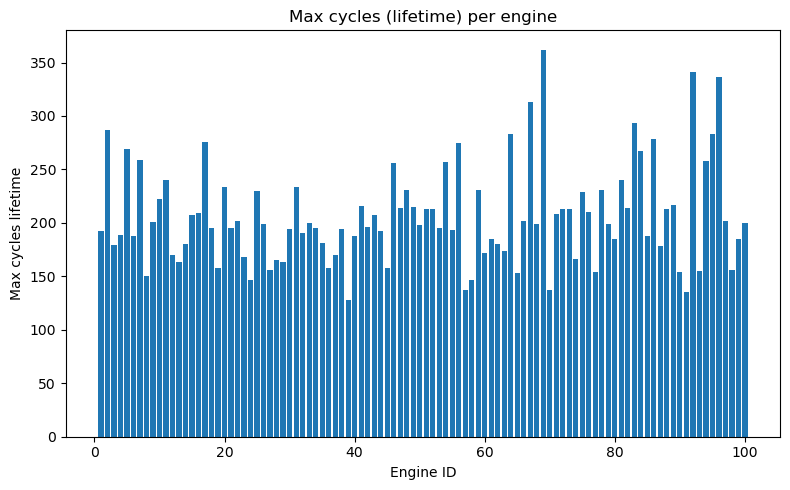

RUL summary:


count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: rul, dtype: float64

In [15]:
# RUL is the number of cycles remaining before failure.
# For each engine, the final observed cycle is treated as the failure cycle.
df_raw["max_cycles"] = df_raw.groupby(id_col)[cycle_col].transform("max")
df_raw[target_col] = df_raw["max_cycles"] - df_raw[cycle_col]

# Quick check of the constructed target.
display(df_raw[[id_col, cycle_col, "max_cycles", target_col]].head())

# Visualize the observed lifetime per engine.
plt.figure(figsize=(8, 5))
plt.bar(df_raw[id_col], df_raw["max_cycles"])
plt.xlabel("Engine ID")
plt.ylabel("Max cycles lifetime")
plt.title("Max cycles (lifetime) per engine")
plt.tight_layout()
plt.show()

# Summary of the target variable.
print("RUL summary:")
display(df_raw[target_col].describe())

# RUL clipping threshold used later in the prediction task.
RUL_CAP = 125 

#### 1.1.2 Descriptive analysis

This section inspects dataset 1 using descriptive statistics and visualizations.

The goal is to understand the data structure, inspect the target variable, and identify variables that may be useful for predicting RUL.

In [16]:
# Inspect the first rows, data types, and missing values.
display(df_raw.head())

print("Dataset information:")
df_raw.info()

print("\nMissing values per column:")
display(df_raw.isna().sum())

,engine_id,cycle,set1,set2,set3,sensor_val1,sensor_val2,sensor_val3,sensor_val4,sensor_val5,...,sensor_val14,sensor_val15,sensor_val16,sensor_val17,sensor_val18,sensor_val19,sensor_val20,sensor_val21,max_cycles,rul
0,1,1,100.0,-0.0007,-0.0004,9046.19,521.66,8138.62,1589.70,554.36,...,1.3,641.82,2388,8.4195,21.61,47.47,14.62,23.4190,192,191
1,1,2,100.0,0.0019,-0.0003,9044.07,522.28,8131.49,1591.82,553.75,...,1.3,642.15,2388,8.4318,21.61,47.49,14.62,23.4236,192,190
2,1,3,100.0,-0.0043,0.0003,9052.94,522.42,8133.23,1587.99,554.26,...,1.3,642.35,2388,8.4178,21.61,47.27,14.62,23.3442,192,189
3,1,4,100.0,0.0007,0.0000,9049.48,522.86,8133.83,1582.79,554.45,...,1.3,642.35,2388,8.3682,21.61,47.13,14.62,23.3739,192,188
4,1,5,100.0,-0.0019,-0.0002,9055.15,522.19,8133.80,1582.85,554.00,...,1.3,642.37,2388,8.4294,21.61,47.28,14.62,23.4044,192,187


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 28 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   engine_id     20631 non-null  int64  
 1   cycle         20631 non-null  int64  
 2   set1          20631 non-null  float64
 3   set2          20631 non-null  float64
 4   set3          20631 non-null  float64
 5   sensor_val1   20631 non-null  float64
 6   sensor_val2   20631 non-null  float64
 7   sensor_val3   20631 non-null  float64
 8   sensor_val4   20631 non-null  float64
 9   sensor_val5   20631 non-null  float64
 10  sensor_val6   20631 non-null  float64
 11  sensor_val7   20631 non-null  float64
 12  sensor_val8   20631 non-null  float64
 13  sensor_val9   20631 non-null  float64
 14  sensor_val10  20631 non-null  float64
 15  sensor_val11  20631 non-null  float64
 16  sensor_val12  20631 non-null  int64  
 17  sensor_val13  20631 non-null  float64
 18  sensor_val14  20

engine_id       0
cycle           0
set1            0
set2            0
set3            0
sensor_val1     0
sensor_val2     0
sensor_val3     0
sensor_val4     0
sensor_val5     0
sensor_val6     0
sensor_val7     0
sensor_val8     0
sensor_val9     0
sensor_val10    0
sensor_val11    0
sensor_val12    0
sensor_val13    0
sensor_val14    0
sensor_val15    0
sensor_val16    0
sensor_val17    0
sensor_val18    0
sensor_val19    0
sensor_val20    0
sensor_val21    0
max_cycles      0
rul             0
dtype: int64

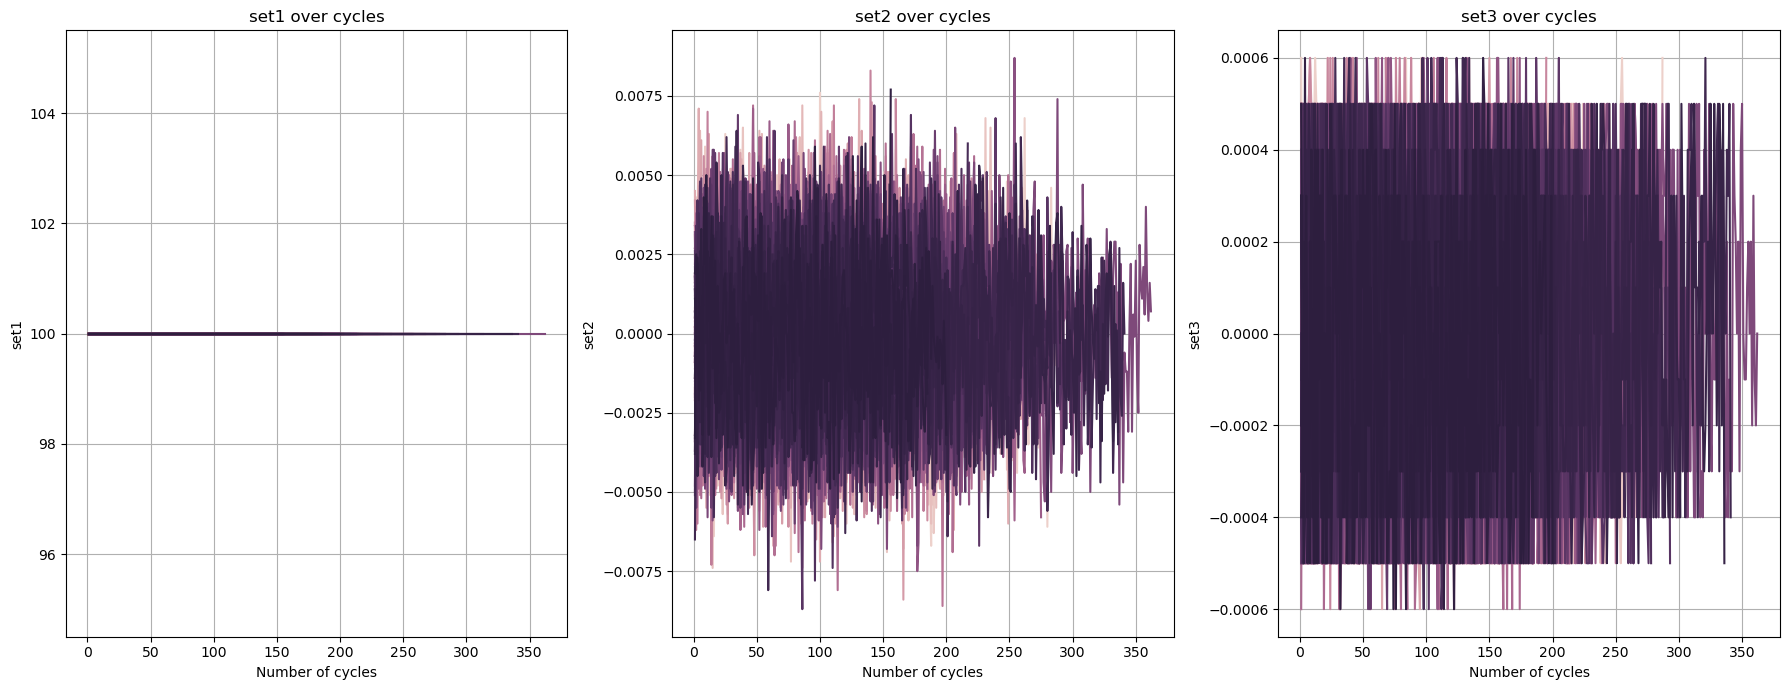

In [17]:
# Visualize the operational settings over cycles.
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
axes = axes.flatten()

for i, setting in enumerate(setting_cols):
    sns.lineplot(
        data=df_raw,
        x=cycle_col,
        y=setting,
        hue=id_col,
        ax=axes[i],
        legend=False
    )
    axes[i].set_title(f"{setting} over cycles")
    axes[i].set_xlabel("Number of cycles")
    axes[i].set_ylabel(setting)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

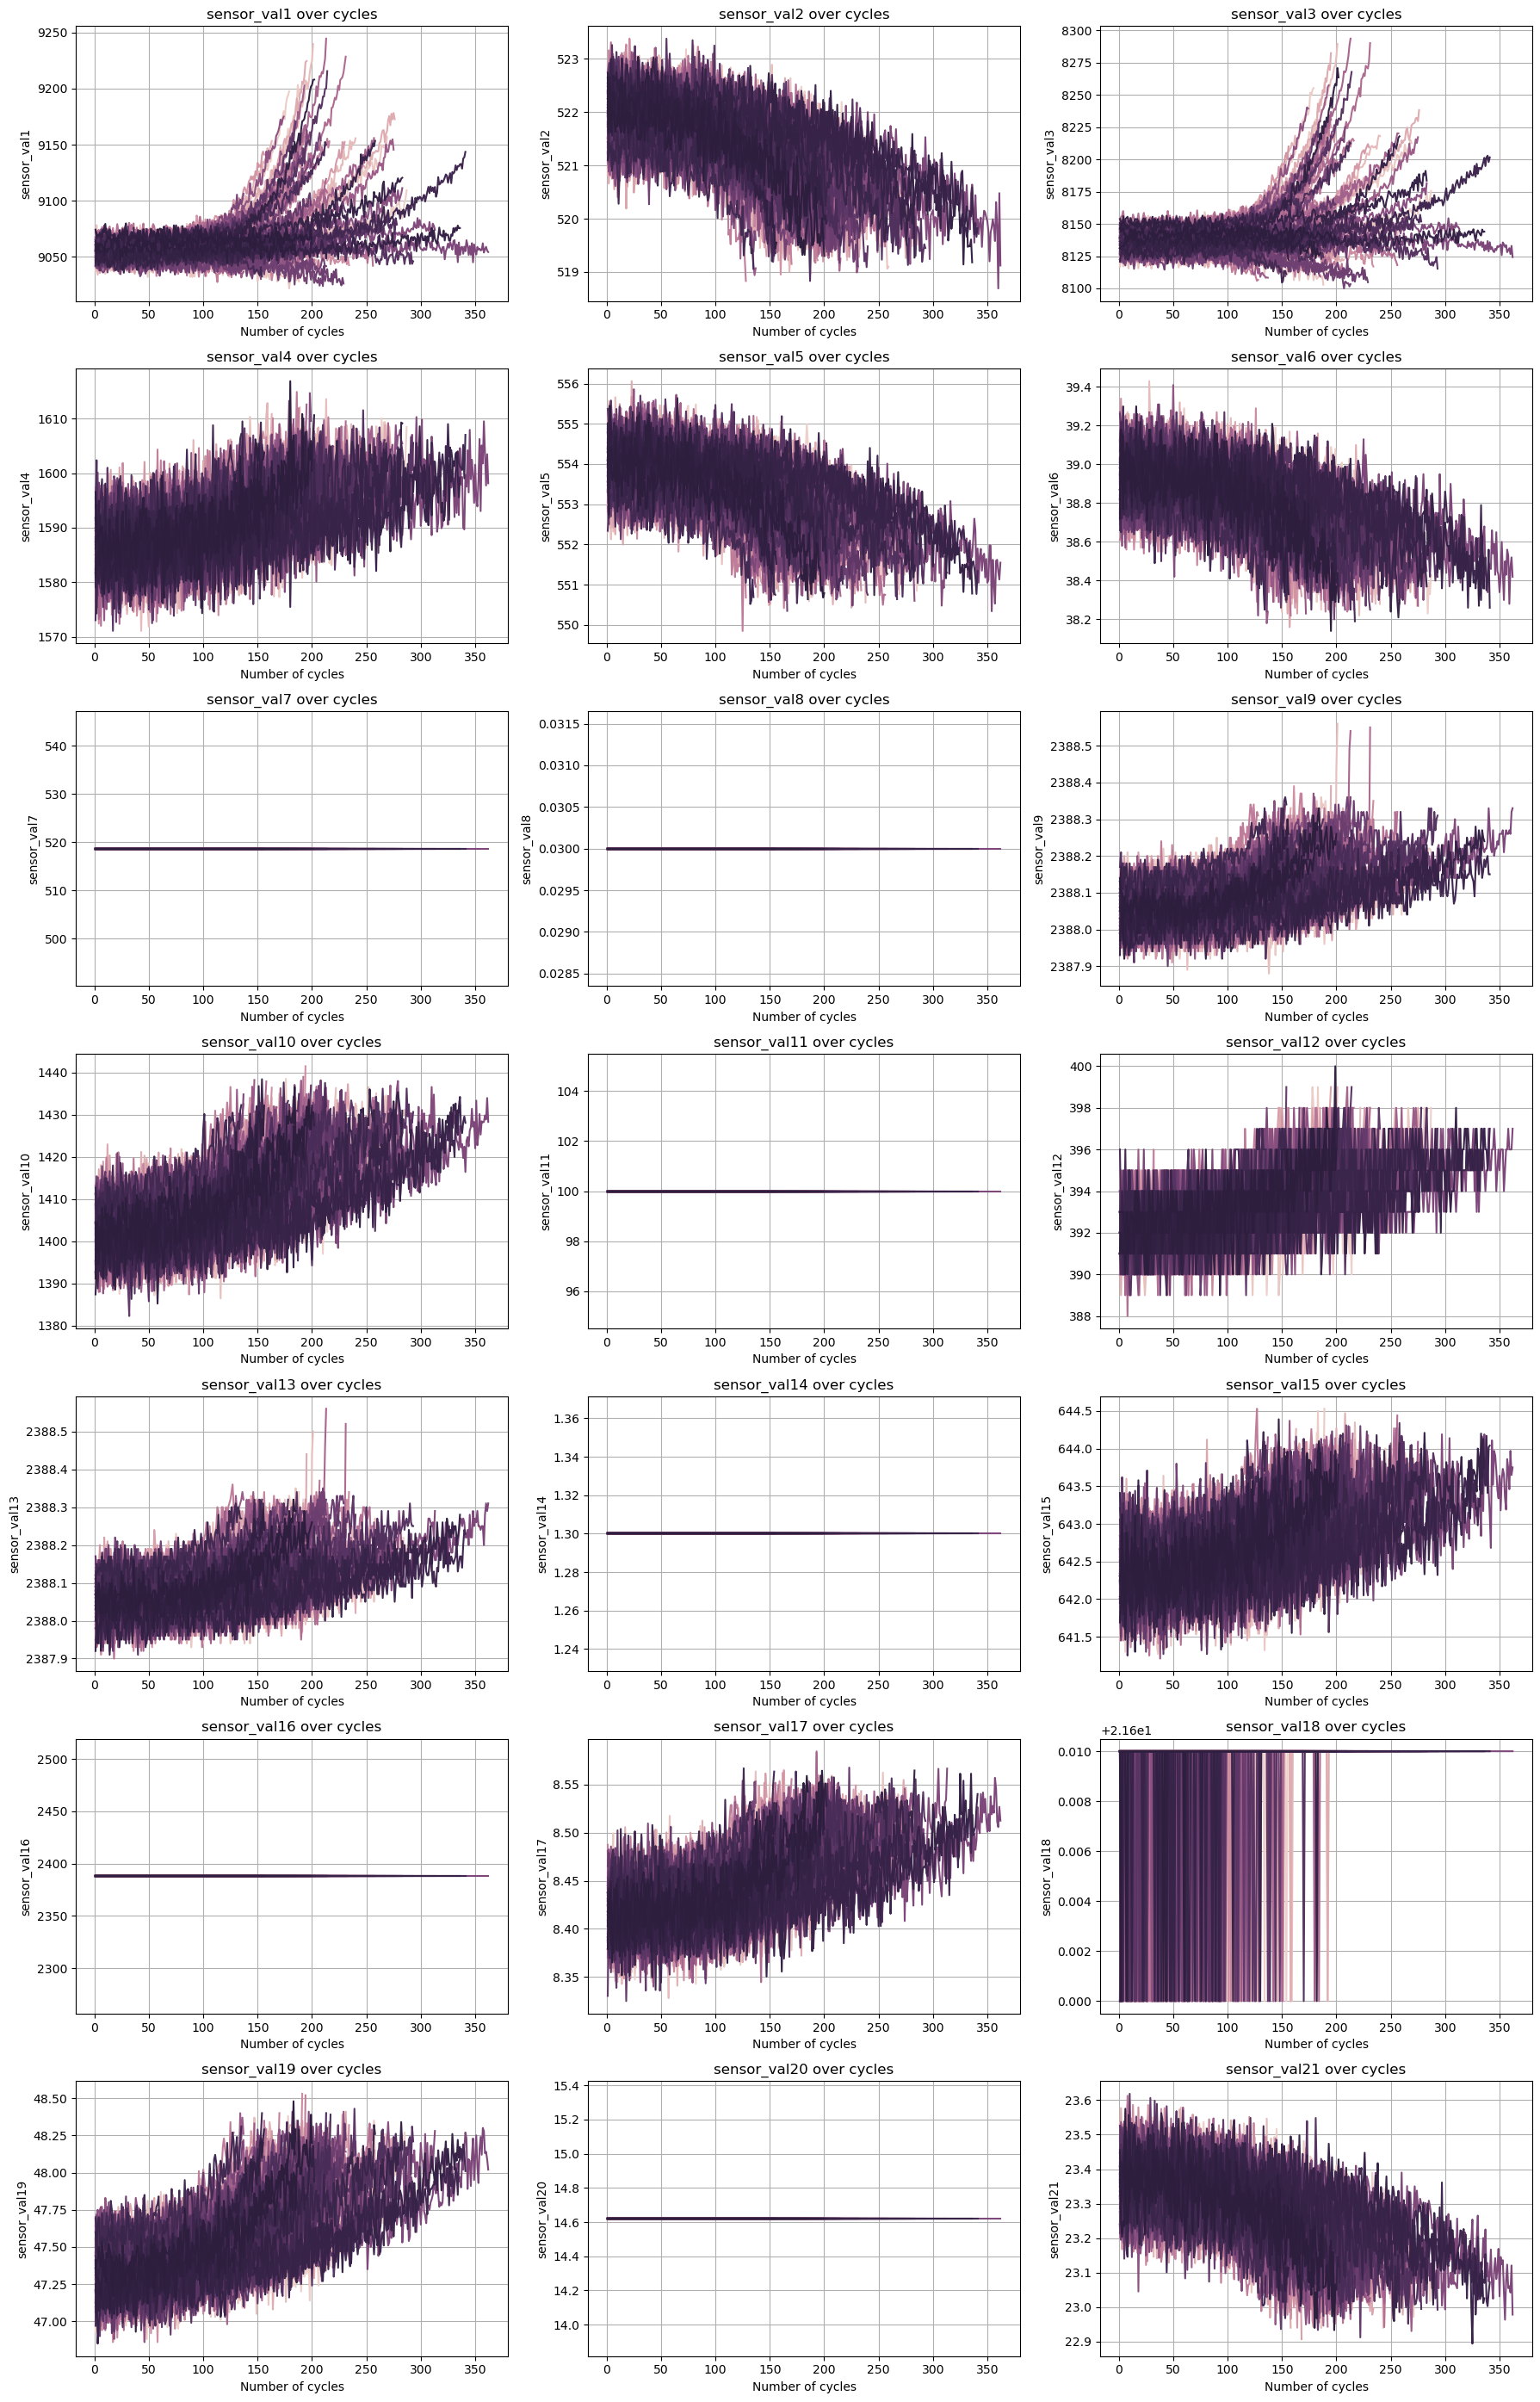

In [18]:
# Visualize the sensor values over cycles.
fig, axes = plt.subplots(7, 3, figsize=(18, 28))
axes = axes.flatten()

for i, sensor in enumerate(sensor_cols):
    sns.lineplot(
        data=df_raw,
        x=cycle_col,
        y=sensor,
        hue=id_col,
        ax=axes[i],
        legend=False
    )
    axes[i].set_title(f"{sensor} over cycles")
    axes[i].set_xlabel("Number of cycles")
    axes[i].set_ylabel(sensor)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [19]:
# Calculate correlations between all numeric variables and RUL.
correlations = df_raw.corr(numeric_only=True)[target_col].sort_values(ascending=False)

print("Correlations with RUL:")
display(correlations)

Correlations with RUL:


rul             1.000000
sensor_val2     0.671983
sensor_val5     0.657223
sensor_val21    0.635662
sensor_val6     0.629428
max_cycles      0.363152
engine_id       0.078753
set3           -0.001948
set2           -0.003198
sensor_val18   -0.128348
sensor_val3    -0.306769
sensor_val1    -0.390102
sensor_val9    -0.562569
sensor_val13   -0.563968
sensor_val4    -0.584520
sensor_val12   -0.606154
sensor_val15   -0.606484
sensor_val17   -0.642667
sensor_val10   -0.678948
sensor_val19   -0.696228
cycle          -0.736241
set1                 NaN
sensor_val7          NaN
sensor_val8          NaN
sensor_val11         NaN
sensor_val14         NaN
sensor_val16         NaN
sensor_val20         NaN
Name: rul, dtype: float64

#### 1.1.3 Feature preparation

This section prepares the input variables for the XGBoost model.

Variables are selected based on their relevance for predicting RUL and their usefulness for applying the same feature structure to dataset 2.

In [20]:
# Make a modeling copy so the original data remains available.
df_model = df_raw.copy()

# Based on the descriptive plots and correlations, these variables are treated as constant or uninformative.
constant_columns = [
    "set1",
    "sensor_val7",
    "sensor_val8",
    "sensor_val11",
    "sensor_val14",
    "sensor_val16",
    "sensor_val20"
]

# max_cycles is only used to construct RUL and cannot be used as a predictor.
# cycle is excluded to avoid directly using time as a shortcut for RUL.
initial_drop_columns = ["max_cycles", cycle_col]

df_model = df_model.drop(columns=constant_columns + initial_drop_columns)

print("Columns kept for initial modeling:")
print(df_model.columns.tolist())

Columns kept for initial modeling:
['engine_id', 'set2', 'set3', 'sensor_val1', 'sensor_val2', 'sensor_val3', 'sensor_val4', 'sensor_val5', 'sensor_val6', 'sensor_val9', 'sensor_val10', 'sensor_val12', 'sensor_val13', 'sensor_val15', 'sensor_val17', 'sensor_val18', 'sensor_val19', 'sensor_val21', 'rul']


In [21]:
# Prepare features, target, and engine groups.
X = df_model.drop(columns=[target_col, id_col])
y = df_model[target_col]
groups = df_model[id_col]

# Split by engine ID to avoid data leakage between train and test sets.
unique_engines = df_model[id_col].unique()

train_engines, test_engines = train_test_split(
    unique_engines,
    test_size=0.2,
    random_state=RANDOM_SEED
)

# Build boolean masks that return True for rows whose engine ID is in the train/test split.
train_mask = df_model[id_col].isin(train_engines) # .isin() checks each row's engine ID against the selected engine set,
test_mask = df_model[id_col].isin(test_engines) # .isin() checks each row's engine ID against the selected engine set,

# Apply the masks to keep only the rows belonging to each split.
X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
groups_train = groups[train_mask] # Needed later for GroupKFold during CV.

print(f"Train: {len(X_train)} rows, {len(train_engines)} engines")
print(f"Test:  {len(X_test)} rows, {len(test_engines)} engines")

Train: 16395 rows, 80 engines
Test:  4236 rows, 20 engines


#### 1.1.4 Initial XGBoost model

This section trains an initial XGBoost regression model to predict RUL.

The initial model is used as a baseline for later validation, feature selection, and hyperparameter tuning.

In [22]:
# Initial XGBoost model with common baseline settings.
model = XGBRegressor(
    n_estimators=100,       # Number of trees built sequentially.
    learning_rate=0.1,      # Step size of each tree contribution.
    max_depth=6,            # Tree complexity.
    random_state=RANDOM_SEED,
    n_jobs=-1
)

# Train the initial model on the training engines.
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

#### 1.1.5 Model validation

This section validates the XGBoost model using held-out validation data and cross-validation.

The validation results are used to assess whether the model generalizes beyond the training engines.

In [23]:
# GroupKFold keeps all cycles of the same engine in the same fold.
gkf = GroupKFold(n_splits=5)

# RMSE is used because large RUL errors are more costly than small errors.
cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    groups=groups_train,
    cv=gkf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rmse_scores = -cv_scores
baseline_cv_rmse = rmse_scores.mean()

print("RMSE per fold:")
for i, score in enumerate(rmse_scores, 1):
    print(f"  Fold {i}: {score:.2f}")

print(f"\nBaseline CV RMSE: {baseline_cv_rmse:.2f} (+/- {rmse_scores.std():.2f})")

RMSE per fold:
  Fold 1: 48.84
  Fold 2: 39.50
  Fold 3: 45.84
  Fold 4: 39.09
  Fold 5: 40.87

Baseline CV RMSE: 42.83 (+/- 3.85)


#### 1.1.6 Feature importance and feature selection

This section inspects feature importance and removes weak or uninformative variables where appropriate.

The reduced feature set is evaluated to check whether it improves or maintains predictive performance.

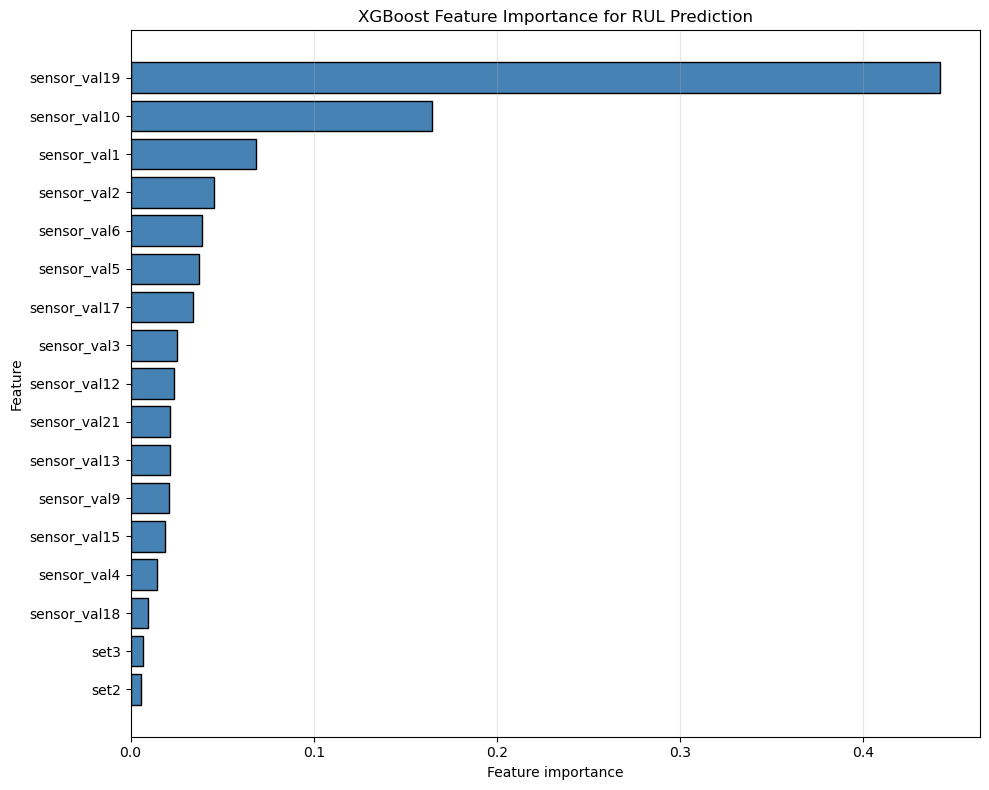

Top 5 most important features:


sensor_val19    0.441693
sensor_val10    0.164378
sensor_val1     0.068628
sensor_val2     0.045796
sensor_val6     0.039007
dtype: float32

Least important features:


set2            0.005776
set3            0.006853
sensor_val18    0.009587
sensor_val4     0.014274
sensor_val15    0.018952
dtype: float32

In [24]:
# Feature importance from the initial XGBoost model.
importances = pd.Series(
    model.feature_importances_,
    index=X_train.columns).sort_values()

plt.figure(figsize=(10, 8))
plt.barh(
    importances.index,
    importances.values,
    color="steelblue",
    edgecolor="black")

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance for RUL Prediction")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
display(importances.sort_values(ascending=False).head())

print("Least important features:")
display(importances.head())

In [25]:
# Based on feature importance and correlation, these variables are removed.
columns_to_drop = ["set2", "set3", "sensor_val18"]

df_model = df_model.drop(columns=columns_to_drop)

print("Additional dropped columns:")
print(columns_to_drop)

print("\nRemaining modeling columns:")
print(df_model.columns.tolist())

Additional dropped columns:
['set2', 'set3', 'sensor_val18']

Remaining modeling columns:
['engine_id', 'sensor_val1', 'sensor_val2', 'sensor_val3', 'sensor_val4', 'sensor_val5', 'sensor_val6', 'sensor_val9', 'sensor_val10', 'sensor_val12', 'sensor_val13', 'sensor_val15', 'sensor_val17', 'sensor_val19', 'sensor_val21', 'rul']


In [26]:
# Rebuild the model data after feature selection.
X = df_model.drop(columns=[target_col, id_col])
y = df_model[target_col]

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=RANDOM_SEED,
    n_jobs=-1)

model.fit(X_train, y_train)

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    groups=groups_train,
    cv=gkf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1)

rmse_scores_after_drops = -cv_scores
feature_selected_cv_rmse = rmse_scores_after_drops.mean()

print(f"CV RMSE after feature selection: {feature_selected_cv_rmse:.2f} (+/- {rmse_scores_after_drops.std():.2f})")
print(f"Baseline CV RMSE:                {baseline_cv_rmse:.2f}")
print(f"Difference:                      {baseline_cv_rmse - feature_selected_cv_rmse:.2f} cycles")

CV RMSE after feature selection: 42.73 (+/- 3.88)
Baseline CV RMSE:                42.83
Difference:                      0.10 cycles


#### 1.1.7 RUL clipping

This section tests a capped RUL target.

RUL clipping is used to reduce the influence of very high RUL values and to focus the model more strongly on the degradation phase that is most relevant for maintenance planning.

In [27]:
# Apply the RUL cap to the training and test targets.
# Values above the cap are set to the cap; values below the cap are unchanged.
y_train_clipped = y_train.clip(upper=RUL_CAP)
y_test_clipped = y_test.clip(upper=RUL_CAP)

# Check how many observations are affected by clipping.
n_clipped_train = (y_train > RUL_CAP).sum()
n_clipped_test = (y_test > RUL_CAP).sum()

print(f"Train: {n_clipped_train}/{len(y_train)} observations clipped ({100 * n_clipped_train / len(y_train):.1f}%)")
print(f"Test:  {n_clipped_test}/{len(y_test)} observations clipped ({100 * n_clipped_test / len(y_test):.1f}%)")

Train: 6315/16395 observations clipped (38.5%)
Test:  1716/4236 observations clipped (40.5%)


In [28]:
# Retrain the same model structure using the clipped RUL target.
model_clipped = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

model_clipped.fit(X_train, y_train_clipped)

cv_scores_clipped = cross_val_score(
    model_clipped,
    X_train,
    y_train_clipped,
    groups=groups_train,
    cv=gkf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rmse_scores_clipped = -cv_scores_clipped
clipped_cv_rmse = rmse_scores_clipped.mean()

print("RMSE per fold with RUL clipping:")
for i, score in enumerate(rmse_scores_clipped, 1):
    print(f"  Fold {i}: {score:.2f}")

print(f"\nCV RMSE with clipping:     {clipped_cv_rmse:.2f} (+/- {rmse_scores_clipped.std():.2f})")
print(f"CV RMSE before clipping:   {feature_selected_cv_rmse:.2f}")
print(f"Improvement from clipping: {feature_selected_cv_rmse - clipped_cv_rmse:.2f} cycles")

RMSE per fold with RUL clipping:
  Fold 1: 22.24
  Fold 2: 16.46
  Fold 3: 19.97
  Fold 4: 18.79
  Fold 5: 19.87

CV RMSE with clipping:     19.46 (+/- 1.88)
CV RMSE before clipping:   42.73
Improvement from clipping: 23.26 cycles


In [29]:
# Evaluate the clipped model on the held-out test engines.
y_pred_clipped = model_clipped.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test_clipped, y_pred_clipped))
mae_test = mean_absolute_error(y_test_clipped, y_pred_clipped)
r2_test = r2_score(y_test_clipped, y_pred_clipped)

print("Test set performance with RUL clipping:")
print(f"RMSE: {rmse_test:.2f} cycles")
print(f"MAE:  {mae_test:.2f} cycles")
print(f"R²:   {r2_test:.3f}")

Test set performance with RUL clipping:
RMSE: 17.05 cycles
MAE:  12.76 cycles
R²:   0.832


#### 1.1.8 Hyperparameter tuning and final model

This section tunes the XGBoost hyperparameters and trains the final prediction model.

The final settings are selected based on validation performance and model stability.

In [30]:
# Hyperparameter search space covering tree complexity, regularization, sampling, and learning process.
param_dist = {
    # Tree complexity
    "max_depth": [3, 5, 7, 9],
    "min_child_weight": [1, 3, 5],

    # Learning process
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],

    # Sampling
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],

    # Regularization
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10],
    "gamma": [0, 0.1, 0.5],
}

search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_SEED, n_jobs=1),
    param_distributions=param_dist,
    n_iter=50,
    cv=gkf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbose=1)

# Run the search on the training data with clipped targets.
search.fit(X_train, y_train_clipped, groups=groups_train)

print("Best hyperparameters found:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")

best_cv_rmse = -search.best_score_

print(f"\nBest CV RMSE:                  {best_cv_rmse:.2f}")
print(f"Previous CV RMSE with clipping: {clipped_cv_rmse:.2f}")
print(f"Improvement from tuning:        {clipped_cv_rmse - best_cv_rmse:.2f} cycles")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best hyperparameters found:
  subsample: 0.7
  reg_lambda: 1
  reg_alpha: 0
  n_estimators: 500
  min_child_weight: 5
  max_depth: 5
  learning_rate: 0.01
  gamma: 0
  colsample_bytree: 1.0

Best CV RMSE:                  19.19
Previous CV RMSE with clipping: 19.46
Improvement from tuning:        0.28 cycles


In [31]:
# Evaluate the tuned model on the held-out test engines.
best_model = search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

rmse_tuned = np.sqrt(mean_squared_error(y_test_clipped, y_pred_tuned))
mae_tuned = mean_absolute_error(y_test_clipped, y_pred_tuned)
r2_tuned = r2_score(y_test_clipped, y_pred_tuned)

print("Test set performance of tuned model:")
print(f"RMSE: {rmse_tuned:.2f} cycles  (previous clipped model: {rmse_test:.2f})")
print(f"MAE:  {mae_tuned:.2f} cycles  (previous clipped model: {mae_test:.2f})")
print(f"R²:   {r2_tuned:.3f}          (previous clipped model: {r2_test:.3f})")

Test set performance of tuned model:
RMSE: 16.78 cycles  (previous clipped model: 17.05)
MAE:  12.77 cycles  (previous clipped model: 12.76)
R²:   0.837          (previous clipped model: 0.832)


#### 1.1.9 Model summary

This section summarizes the final model settings and validation performance.

The selected model is used in Section 1.2 to predict the RUL values for dataset 2.

In [32]:
model_summary = pd.DataFrame({
    "Model step": [
        "Initial model",
        "After feature selection",
        "After RUL clipping",
        "After hyperparameter tuning"
    ],
    "Validation RMSE": [
        baseline_cv_rmse,
        feature_selected_cv_rmse,
        clipped_cv_rmse,
        best_cv_rmse
    ]
})

display(model_summary)

print("Final selected features:")
print(X_train.columns.tolist())

print("\nFinal model hyperparameters:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")

,Model step,Validation RMSE
0,Initial model,42.826968
1,After feature selection,42.727398
2,After RUL clipping,19.464244
3,After hyperparameter tuning,19.185269


Final selected features:
['sensor_val1', 'sensor_val2', 'sensor_val3', 'sensor_val4', 'sensor_val5', 'sensor_val6', 'sensor_val9', 'sensor_val10', 'sensor_val12', 'sensor_val13', 'sensor_val15', 'sensor_val17', 'sensor_val19', 'sensor_val21']

Final model hyperparameters:
  subsample: 0.7
  reg_lambda: 1
  reg_alpha: 0
  n_estimators: 500
  min_child_weight: 5
  max_depth: 5
  learning_rate: 0.01
  gamma: 0
  colsample_bytree: 1.0


### **1.2 Prediction**

This section uses the final XGBoost model to predict the RUL values for dataset 2 and compares these predictions with the consultancy predictions.

#### 1.2.1 RUL prediction for dataset 2

This section applies the final model to dataset 2.

The prediction is made for each engine, and the resulting RUL values are rounded to integers for use in the optimization task.

In [33]:
# Apply the same feature drops to dataset 2 as used for dataset 1.
df_pred_processed = df_pred.drop(columns=constant_columns + columns_to_drop)

# For each engine in dataset 2, only the last available cycle is used for prediction.
# This represents the current observed state of each engine.
last_cycle_idx = df_pred_processed.groupby(id_col)[cycle_col].idxmax()
df_pred_last = df_pred_processed.loc[last_cycle_idx].copy()

# Sort by engine ID for a clean and consistent prediction table.
df_pred_last = df_pred_last.sort_values(id_col).reset_index(drop=True)

print("Last observed row per engine:")
display(df_pred_last.head())
print(f"Number of engines prepared for prediction: {len(df_pred_last)}")

Last observed row per engine:


,engine_id,cycle,sensor_val1,sensor_val2,sensor_val3,sensor_val4,sensor_val5,sensor_val6,sensor_val9,sensor_val10,sensor_val12,sensor_val13,sensor_val15,sensor_val17,sensor_val19,sensor_val21
0,1,31,9056.40,521.79,8130.11,1581.22,554.42,38.81,2388.06,1398.91,393,2388.08,642.58,8.4024,47.23,23.3552
1,2,49,9044.77,521.74,8126.90,1586.59,553.52,38.81,2388.09,1410.83,391,2388.10,642.55,8.4505,47.67,23.2618
2,3,126,9049.26,520.83,8131.46,1589.75,552.59,38.93,2388.14,1418.89,395,2388.16,642.88,8.4119,47.88,23.2740
3,4,106,9051.30,521.88,8133.64,1594.53,552.64,38.58,2388.11,1406.88,395,2388.13,642.78,8.4634,47.65,23.2581
4,5,98,9053.99,521.00,8125.74,1589.94,553.29,38.75,2388.15,1419.36,394,2388.10,642.27,8.4362,47.46,23.4117


Number of engines prepared for prediction: 100


In [34]:
# For the final prediction, retrain on all available training data using the best hyperparameters.
# This uses the complete labeled dataset after the validation and tuning choices have been made.
X_full = df_model.drop(columns=[target_col, id_col])
y_full = df_model[target_col].clip(upper=RUL_CAP)

final_model = XGBRegressor(
    **search.best_params_,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

final_model.fit(X_full, y_full)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [35]:
# Select only the feature columns that the final model was trained on.
feature_cols = X_full.columns.tolist()
X_pred = df_pred_last[feature_cols]

# Generate predicted RUL values.
predictions_raw = final_model.predict(X_pred)

# Round predictions to integers, as required for the optimization task.
predictions_int = np.round(predictions_raw).astype(int)

# RUL cannot be negative.
predictions_int = np.clip(predictions_int, a_min=0, a_max=None)

#### 1.2.2 Final predicted RUL table

This section stores the final model-based RUL predictions in a clean table.

The table contains one predicted integer RUL value per engine and is used as input for the optimization task.

In [36]:
# Store the final model-based RUL predictions in a clean table.
rul_predictions = pd.DataFrame({
    id_col: df_pred_last[id_col].values,
    "predicted_rul": predictions_int
})

# Dictionary format used later in the optimization task.
own_rul_dict = dict(zip(rul_predictions[id_col], rul_predictions["predicted_rul"]))

print("Prediction summary:")
display(rul_predictions["predicted_rul"].describe())

print("First 10 predictions:")
display(rul_predictions.head(10))

Prediction summary:


count    100.000000
mean      78.250000
std       38.414637
min        7.000000
25%       46.750000
50%       96.500000
75%      113.250000
max      122.000000
Name: predicted_rul, dtype: float64

First 10 predictions:


,engine_id,predicted_rul
0,1,119
1,2,116
2,3,64
3,4,95
4,5,106
5,6,106
6,7,103
7,8,100
8,9,103
9,10,105


In [37]:
# Save the predictions so they can be inspected separately if needed.
prediction_output_path = PROJECT_DIR / "my_rul_predictions.csv"
rul_predictions.to_csv(prediction_output_path, index=False)

print(f"Predictions saved to: {prediction_output_path}")

Predictions saved to: C:\Users\larsk\OneDrive\Documenten\JADS\Semester 2\Prescriptive Algorithms\Assignment 3\PA_Assignment_3_Zip_Yvette\PA_Assignment_3\my_rul_predictions.csv


#### 1.2.3 Comparison with consultancy predictions

This section compares the model-based RUL predictions with the consultancy predictions.

The comparison uses numerical difference metrics and a visual inspection to assess whether the two prediction sets differ meaningfully.

In [38]:
# Rename consultancy columns to match the model-based prediction table.
df_consultancy_renamed = df_consultancy.rename(columns={
    "id": id_col,
    "RUL": "consultancy_rul"
})

# Ensure both RUL columns are integer-valued.
df_consultancy_renamed["consultancy_rul"] = df_consultancy_renamed["consultancy_rul"].round().astype(int)

# Merge both prediction sets by engine ID.
comparison = rul_predictions.merge(df_consultancy_renamed, on=id_col)

# Positive difference means the model-based prediction is higher than the consultancy prediction.
comparison["difference"] = comparison["predicted_rul"] - comparison["consultancy_rul"]

print("First 10 rows of the prediction comparison:")
display(comparison.head(10))

print(f"Merged {len(comparison)} engines. Expected: 100.")

print("\nSummary statistics of prediction differences:")
display(comparison["difference"].describe())

First 10 rows of the prediction comparison:


,engine_id,predicted_rul,consultancy_rul,difference
0,1,119,135,-16
1,2,116,125,-9
2,3,64,63,1
3,4,95,100,-5
4,5,106,103,3
5,6,106,122,-16
6,7,103,106,-3
7,8,100,90,10
8,9,103,121,-18
9,10,105,67,38


Merged 100 engines. Expected: 100.

Summary statistics of prediction differences:


count    100.00000
mean      -4.65000
std       21.05902
min      -73.00000
25%      -14.25000
50%       -2.00000
75%        5.25000
max       48.00000
Name: difference, dtype: float64

In [39]:
# Agreement metrics.
mae_diff = np.mean(np.abs(comparison["difference"]))
rmse_diff = np.sqrt(np.mean(comparison["difference"] ** 2))
mean_diff = comparison["difference"].mean()

print("Difference metrics:")
print(f"Mean difference (model - consultancy): {mean_diff:+.2f} cycles")
print(f"MAE between predictions:               {mae_diff:.2f} cycles")
print(f"RMSE between predictions:              {rmse_diff:.2f} cycles")

# Pearson correlation checks whether the two prediction sets rank engines similarly.
pearson_r, pearson_p = stats.pearsonr(
    comparison["predicted_rul"],
    comparison["consultancy_rul"]
)

print(f"\nPearson correlation: r = {pearson_r:.3f}, p = {pearson_p:.4f}")

# Paired t-test checks for a systematic average difference.
t_stat, t_pval = stats.ttest_rel(
    comparison["predicted_rul"],
    comparison["consultancy_rul"]
)

print(f"Paired t-test: t = {t_stat:.3f}, p = {t_pval:.4f}")

# Wilcoxon signed-rank test is a non-parametric alternative.
w_stat, w_pval = stats.wilcoxon(
    comparison["predicted_rul"],
    comparison["consultancy_rul"]
)

print(f"Wilcoxon test: W = {w_stat:.3f}, p = {w_pval:.4f}")

alpha = 0.05
print("\nInterpretation:")
if t_pval < alpha:
    print(f"The paired t-test indicates a significant difference between the two prediction sets (p < {alpha}).")
else:
    print(f"The paired t-test does not indicate a significant difference between the two prediction sets (p >= {alpha}).")

Difference metrics:
Mean difference (model - consultancy): -4.65 cycles
MAE between predictions:               14.61 cycles
RMSE between predictions:              21.46 cycles

Pearson correlation: r = 0.908, p = 0.0000
Paired t-test: t = -2.208, p = 0.0295
Wilcoxon test: W = 1775.500, p = 0.0434

Interpretation:
The paired t-test indicates a significant difference between the two prediction sets (p < 0.05).


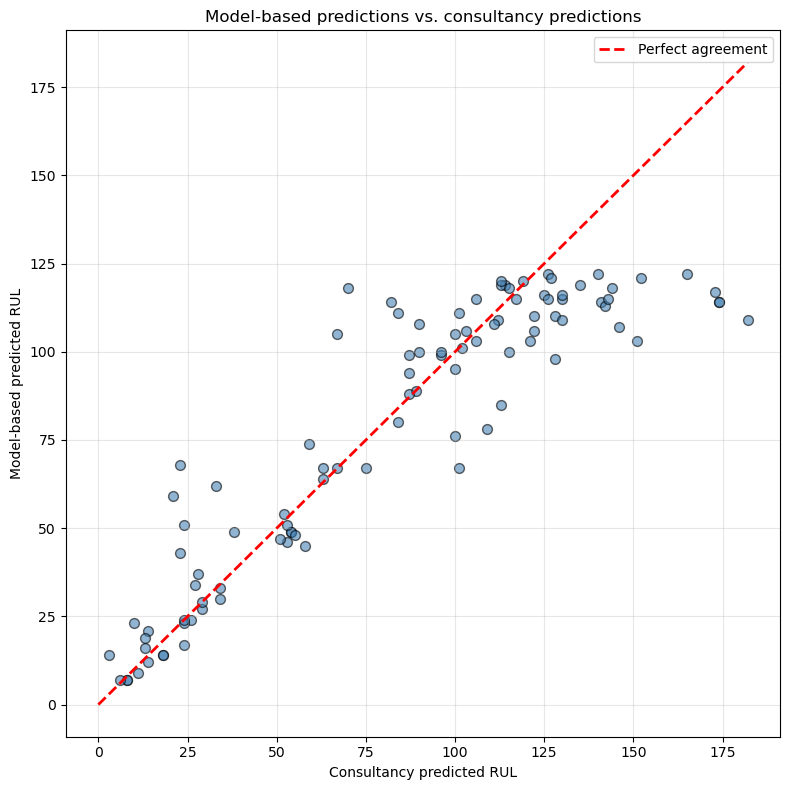

Comparison plot saved to: C:\Users\larsk\OneDrive\Documenten\JADS\Semester 2\Prescriptive Algorithms\Assignment 3\PA_Assignment_3_Zip_Yvette\PA_Assignment_3\prediction_comparison.png


In [40]:
# Visualize agreement between model-based and consultancy predictions.
plt.figure(figsize=(8, 8))

plt.scatter(
    comparison["consultancy_rul"],
    comparison["predicted_rul"],
    alpha=0.6,
    s=50,
    edgecolor="black",
    color="steelblue"
)

# Line of perfect agreement.
max_val = max(
    comparison["predicted_rul"].max(),
    comparison["consultancy_rul"].max()
)

plt.plot(
    [0, max_val],
    [0, max_val],
    "r--",
    linewidth=2,
    label="Perfect agreement"
)

plt.xlabel("Consultancy predicted RUL")
plt.ylabel("Model-based predicted RUL")
plt.title("Model-based predictions vs. consultancy predictions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

comparison_plot_path = PROJECT_DIR / "prediction_comparison.png"
plt.savefig(comparison_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Comparison plot saved to: {comparison_plot_path}")

#### 1.2.4 Prediction findings

This section summarizes the main findings from the comparison between the model-based RUL predictions and the consultancy predictions.

In [41]:
prediction_findings = pd.DataFrame({
    "Metric": [
        "Mean model-based RUL",
        "Mean consultancy RUL",
        "Mean difference",
        "MAE between predictions",
        "RMSE between predictions",
        "Pearson correlation",
        "Paired t-test p-value",
        "Wilcoxon p-value"
    ],
    "Value": [
        comparison["predicted_rul"].mean(),
        comparison["consultancy_rul"].mean(),
        mean_diff,
        mae_diff,
        rmse_diff,
        pearson_r,
        t_pval,
        w_pval
    ]
})

display(prediction_findings)

print("Prediction task completed.")
print("The model-based RUL predictions are available as 'rul_predictions' and 'own_rul_dict'.")

,Metric,Value
0,Mean model-based RUL,78.250000
1,Mean consultancy RUL,82.900000
2,Mean difference,-4.650000
3,MAE between predictions,14.610000
4,RMSE between predictions,21.463224
5,Pearson correlation,0.907569
6,Paired t-test p-value,0.029547
7,Wilcoxon p-value,0.043411


Prediction task completed.
The model-based RUL predictions are available as 'rul_predictions' and 'own_rul_dict'.


## **2. Optimization Task**

---

This section develops and applies a Genetic Algorithm to schedule maintenance for the 100 engines in dataset 2.

The objective is to minimize total penalty costs over a 30-day planning horizon while respecting team availability, maintenance durations, and feasibility constraints.

### **2.0 Optimization Set-Up**

This section defines the optimization-specific inputs used in the maintenance scheduling problem.

In [42]:
# Fixed planning settings from the assignment.
CURRENT_DAY = 1
PLANNING_HORIZON = 30

# Engines in dataset 2.
ENGINE_IDS = list(range(1, 101))

# Maintenance teams.
TEAMS = ["T1", "T2", "T3", "T4"]

# Team types: T1 and T3 are type A; T2 and T4 are type B.
TEAM_TYPE = {
    "T1": "A",
    "T2": "B",
    "T3": "A",
    "T4": "B"}

TYPE_A_TEAMS = [team for team in TEAMS if TEAM_TYPE[team] == "A"]
TYPE_B_TEAMS = [team for team in TEAMS if TEAM_TYPE[team] == "B"]

print("Optimization set-up:")
print(f"Current day:       {CURRENT_DAY}")
print(f"Planning horizon:  {PLANNING_HORIZON} days")
print(f"Number of engines: {len(ENGINE_IDS)}")
print(f"Teams:             {TEAMS}")
print(f"Type A teams:      {TYPE_A_TEAMS}")
print(f"Type B teams:      {TYPE_B_TEAMS}")

Optimization set-up:
Current day:       1
Planning horizon:  30 days
Number of engines: 100
Teams:             ['T1', 'T2', 'T3', 'T4']
Type A teams:      ['T1', 'T3']
Type B teams:      ['T2', 'T4']


#### 2.0.1 Maintenance and penalty parameters

This section defines the maintenance duration and penalty cost parameters for each engine.

The maintenance duration depends on the engine and team type. The penalty cost depends on how many days an engine remains unmaintained after its safety due date.

In [43]:
def mu_A(engine_id):
    # Maintenance duration for engine j when maintained by a type A team.
    if 1 <= engine_id <= 20:
        return 5
    if 21 <= engine_id <= 55:
        return 3
    if 56 <= engine_id <= 80:
        return 4
    if 81 <= engine_id <= 100:
        return 5

    raise ValueError(f"Invalid engine ID: {engine_id}")


def mu_B(engine_id):
    # Maintenance duration for engine j when maintained by a type B team.
    mu_a = mu_A(engine_id)

    if 1 <= engine_id <= 25:
        return mu_a - 1
    if 26 <= engine_id <= 70:
        return mu_a + 3
    if 71 <= engine_id <= 100:
        return mu_a + 2

    raise ValueError(f"Invalid engine ID: {engine_id}")


def maintenance_duration(engine_id, team):
    # Return the maintenance duration for a given engine-team combination.
    if team not in TEAM_TYPE:
        raise ValueError(f"Invalid team: {team}")

    if TEAM_TYPE[team] == "A":
        return mu_A(engine_id)

    return mu_B(engine_id)

def penalty_coefficient(engine_id):
    # Penalty coefficient c_j for engine j.
    if 1 <= engine_id <= 25:
        return 4
    if 26 <= engine_id <= 45:
        return 2
    if 46 <= engine_id <= 75:
        return 5
    if 76 <= engine_id <= 100:
        return 6

    raise ValueError(f"Invalid engine ID: {engine_id}")


def safety_due_date(rul_value):
    # Safety due date t_s = t_1 + R_j - 1.
    return CURRENT_DAY + int(rul_value) - 1


def daily_penalty(engine_id, overdue_days):
    # Daily penalty cost for an overdue engine.
    # The daily cost is capped at 250.
    c_j = penalty_coefficient(engine_id)
    return min(c_j * (overdue_days ** 2), 250)


def total_penalty_until_day(engine_id, due_date, last_penalty_day):
    # Total penalty from the day after the safety due date up to last_penalty_day.
    # For an unscheduled engine, last_penalty_day is the end of the planning horizon.
    # For a scheduled engine, last_penalty_day is the maintenance completion day.
    if last_penalty_day <= due_date:
        return 0

    total = 0

    for day in range(due_date + 1, last_penalty_day + 1):
        overdue_days = day - due_date
        total += daily_penalty(engine_id, overdue_days)

    return total


def latest_start_day(engine_id, team):
    # Latest possible start day that allows maintenance to finish within the horizon.
    duration = maintenance_duration(engine_id, team)
    return PLANNING_HORIZON - duration + 1

In [44]:
# Parameter check table for inspection.
parameter_check = pd.DataFrame({
    "engine_id": ENGINE_IDS,
    "duration_A": [mu_A(engine_id) for engine_id in ENGINE_IDS],
    "duration_B": [mu_B(engine_id) for engine_id in ENGINE_IDS],
    "penalty_coefficient": [penalty_coefficient(engine_id) for engine_id in ENGINE_IDS]
})

display(parameter_check.head(10))
display(parameter_check.tail(10))

,engine_id,duration_A,duration_B,penalty_coefficient
0,1,5,4,4
1,2,5,4,4
2,3,5,4,4
3,4,5,4,4
4,5,5,4,4
5,6,5,4,4
6,7,5,4,4
7,8,5,4,4
8,9,5,4,4
9,10,5,4,4


,engine_id,duration_A,duration_B,penalty_coefficient
90,91,5,7,6
91,92,5,7,6
92,93,5,7,6
93,94,5,7,6
94,95,5,7,6
95,96,5,7,6
96,97,5,7,6
97,98,5,7,6
98,99,5,7,6
99,100,5,7,6


#### 2.0.2 RUL inputs

This section prepares the RUL inputs used by the optimization task.

The same Genetic Algorithm is later applied to both the model-based RUL predictions and the consultancy RUL predictions.

In [45]:
# The prediction task should create 'rul_predictions' and 'own_rul_dict'.
# This fallback allows the optimization section to run if the saved predictions are available.
if "rul_predictions" not in globals():
    prediction_output_path = PROJECT_DIR / "my_rul_predictions.csv"

    if not prediction_output_path.exists():
        raise FileNotFoundError(
            "Could not find 'rul_predictions' in memory or 'my_rul_predictions.csv' in the project folder."
        )

    rul_predictions = pd.read_csv(prediction_output_path)

# Standardize model-based RUL input.
rul_predictions = rul_predictions.copy()
rul_predictions[id_col] = rul_predictions[id_col].astype(int)
rul_predictions["predicted_rul"] = rul_predictions["predicted_rul"].astype(int)

own_rul_dict = dict(zip(rul_predictions[id_col], rul_predictions["predicted_rul"]))

# Standardize consultancy RUL input.
consultancy_rul_table = df_consultancy.rename(columns={
    "id": id_col,
    "RUL": "consultancy_rul"
}).copy()

consultancy_rul_table[id_col] = consultancy_rul_table[id_col].astype(int)
consultancy_rul_table["consultancy_rul"] = consultancy_rul_table["consultancy_rul"].round().astype(int)

consultancy_rul_dict = dict(zip(
    consultancy_rul_table[id_col],
    consultancy_rul_table["consultancy_rul"]
))

In [46]:
# Check that both RUL inputs contain all 100 engines.
missing_own = sorted(set(ENGINE_IDS) - set(own_rul_dict.keys()))
missing_consultancy = sorted(set(ENGINE_IDS) - set(consultancy_rul_dict.keys()))

if missing_own:
    raise ValueError(f"Missing model-based RUL predictions for engines: {missing_own}")

if missing_consultancy:
    raise ValueError(f"Missing consultancy RUL predictions for engines: {missing_consultancy}")

print("RUL inputs prepared successfully.")
print(f"Model-based RUL values: {len(own_rul_dict)}")
print(f"Consultancy RUL values: {len(consultancy_rul_dict)}")

RUL inputs prepared successfully.
Model-based RUL values: 100
Consultancy RUL values: 100


In [47]:
def summarize_rul_input(rul_dict, label):
    # Summarize a set of RUL inputs for the optimization task.
    due_dates = {
        engine_id: safety_due_date(rul_dict[engine_id])
        for engine_id in ENGINE_IDS
    }

    candidate_engines = [
        engine_id
        for engine_id in ENGINE_IDS
        if due_dates[engine_id] < PLANNING_HORIZON
    ]

    summary = pd.DataFrame({
        "Input": [label],
        "Mean RUL": [np.mean(list(rul_dict.values()))],
        "Minimum RUL": [np.min(list(rul_dict.values()))],
        "Maximum RUL": [np.max(list(rul_dict.values()))],
        "Engines with safety due date < 30": [len(candidate_engines)]
    })

    return summary


rul_input_summary = pd.concat([
    summarize_rul_input(own_rul_dict, "Model-based predictions"),
    summarize_rul_input(consultancy_rul_dict, "Consultancy predictions")
], ignore_index=True)

display(rul_input_summary)

,Input,Mean RUL,Minimum RUL,Maximum RUL,Engines with safety due date < 30
0,Model-based predictions,78.25,7,122,18
1,Consultancy predictions,82.90,3,182,24


#### 2.0.3 Helper functions

This section defines helper functions for schedule feasibility, penalty calculation, and readable output formatting.

Keeping these functions separate makes the Genetic Algorithm easier to inspect and validate.

In [48]:
def team_is_available(team_schedule, team, start_day, end_day):
    # Check whether a team is available for the full interval [start_day, end_day].
    for busy_start, busy_end, _ in team_schedule[team]:
        overlaps = not (end_day < busy_start or start_day > busy_end)

        if overlaps:
            return False

    return True


def get_candidate_engines(rul_dict):
    # Select engines with a safety due date inside the planning horizon.
    # Engines with safety due date equal to 30 are not urgent, because they still work on day 30.
    due_dates = {
        engine_id: safety_due_date(rul_dict[engine_id])
        for engine_id in ENGINE_IDS
    }

    candidate_engines = [
        engine_id
        for engine_id in ENGINE_IDS
        if due_dates[engine_id] < PLANNING_HORIZON
    ]

    return candidate_engines, due_dates

### **2.1 Genetic Algorithm**

This section implements the Genetic Algorithm used to solve the maintenance scheduling problem.

The algorithm accepts predicted RUL values for all engines as input and returns a feasible maintenance schedule with the corresponding total penalty cost.

#### 2.1.1 Individual representation and initialization

This section defines how a maintenance schedule is represented as an individual in the Genetic Algorithm.

Each individual must encode which engines are maintained, which team performs the maintenance, and when maintenance starts.

In [49]:
# Map teams to integers so that each gene has a compact representation.
TEAM_TO_INT = {team: idx + 1 for idx, team in enumerate(TEAMS)}
INT_TO_TEAM = {idx + 1: team for idx, team in enumerate(TEAMS)}

# A gene with team code 0 means that the engine is not scheduled for maintenance.
UNSCHEDULED_GENE = (0, 0)

# Create DEAP classes safely for repeated notebook runs.
if not hasattr(creator, "FitnessMinMaintenance"):
    creator.create("FitnessMinMaintenance", base.Fitness, weights=(-1.0,))

if not hasattr(creator, "IndividualMaintenance"):
    creator.create("IndividualMaintenance", list, fitness=creator.FitnessMinMaintenance)

In [50]:
def create_random_gene(engine_id, unscheduled_prob):
    # With some probability, the engine is left unscheduled.
    if random.random() < unscheduled_prob:
        return UNSCHEDULED_GENE

    # Otherwise, assign a random team and feasible start day.
    team = random.choice(TEAMS)
    max_start = latest_start_day(engine_id, team)

    # If the job cannot fit within the planning horizon, leave it unscheduled.
    if max_start < 1:
        return UNSCHEDULED_GENE

    start_day = random.randint(1, max_start)

    return (TEAM_TO_INT[team], start_day)


def create_individual(candidate_engines, due_dates, unscheduled_prob):
    # The individual has one gene for each candidate engine.
    # Gene i belongs to candidate_engines[i].
    genes = [
        create_random_gene(engine_id, unscheduled_prob)
        for engine_id in candidate_engines
    ]

    # Repair immediately so the initial population starts from feasible schedules.
    repaired, _, _ = decode_and_repair(
        genes,
        candidate_engines,
        due_dates
    )

    return creator.IndividualMaintenance(repaired)

#### 2.1.2 Fitness function and feasibility handling

This section defines how each maintenance schedule is evaluated.

The fitness value is the total penalty cost, so lower values are better. Feasibility is checked and repaired where needed to avoid invalid team overlaps, duplicate maintenance assignments, or jobs outside the planning horizon.

In [51]:
def find_repair_position(engine_id, preferred_team, team_schedule):
    # Try to repair a job by first trying the original team.
    # If that is not possible, try all other teams.
    candidate_teams = [preferred_team] + [
        team for team in TEAMS
        if team != preferred_team
    ]

    for team in candidate_teams:
        duration = maintenance_duration(engine_id, team)
        max_start = latest_start_day(engine_id, team)

        for start_day in range(1, max_start + 1):
            end_day = start_day + duration - 1

            if team_is_available(team_schedule, team, start_day, end_day):
                return team, start_day, end_day

    # If no feasible team/start-day combination is found, no repair is possible.
    return None

In [52]:
def decode_and_repair(individual, candidate_engines, due_dates):
    # This function enforces the schedule constraints:
    # 1. one team can only work on one engine at a time;
    # 2. one engine can be maintained at most once;
    # 3. each scheduled job must finish within the planning horizon.

    team_schedule = {team: [] for team in TEAMS}

    # Schedule more urgent engines first during repair.
    indexed_jobs = list(enumerate(candidate_engines))
    indexed_jobs.sort(key=lambda x: due_dates[x[1]])

    repaired_temp = [UNSCHEDULED_GENE] * len(candidate_engines)

    for idx, engine_id in indexed_jobs:
        team_code, start_day = individual[idx]

        # Team code 0 means that this engine is intentionally not scheduled.
        if team_code == 0:
            repaired_temp[idx] = UNSCHEDULED_GENE
            continue

        team = INT_TO_TEAM.get(team_code)

        # Invalid team codes are repaired by leaving the engine unscheduled.
        if team is None:
            repaired_temp[idx] = UNSCHEDULED_GENE
            continue

        duration = maintenance_duration(engine_id, team)
        end_day = start_day + duration - 1

        # Repair if the proposed job is outside the horizon or overlaps on the team.
        needs_repair = (
            start_day < 1
            or end_day > PLANNING_HORIZON
            or not team_is_available(team_schedule, team, start_day, end_day)
        )

        if needs_repair:
            repaired_candidate = find_repair_position(
                engine_id,
                team,
                team_schedule
            )

            # If no feasible repair exists, leave the engine unscheduled.
            if repaired_candidate is None:
                repaired_temp[idx] = UNSCHEDULED_GENE
                continue

            team, start_day, end_day = repaired_candidate
            team_code = TEAM_TO_INT[team]

        # Once this point is reached, the job is feasible.
        team_schedule[team].append((start_day, end_day, engine_id))
        repaired_temp[idx] = (team_code, start_day)

    # Build readable solution rows and compute total penalty.
    solution_rows = []
    total_penalty_value = 0

    for idx, engine_id in enumerate(candidate_engines):
        team_code, start_day = repaired_temp[idx]
        due_date = due_dates[engine_id]

        if team_code == 0:
            # Unscheduled engines accumulate penalty until the end of the horizon.
            engine_penalty = total_penalty_until_day(
                engine_id=engine_id,
                due_date=due_date,
                last_penalty_day=PLANNING_HORIZON
            )

            solution_rows.append({
                "engine_id": engine_id,
                "maintained": 0,
                "team": None,
                "team_type": None,
                "start_day": None,
                "end_day": None,
                "duration": None,
                "safety_due_date": due_date,
                "penalty_cost": engine_penalty
            })

        else:
            team = INT_TO_TEAM[team_code]
            duration = maintenance_duration(engine_id, team)
            end_day = start_day + duration - 1

            # Maintained engines accumulate penalty until maintenance completion.
            engine_penalty = total_penalty_until_day(
                engine_id=engine_id,
                due_date=due_date,
                last_penalty_day=end_day
            )

            solution_rows.append({
                "engine_id": engine_id,
                "maintained": 1,
                "team": team,
                "team_type": TEAM_TYPE[team],
                "start_day": start_day,
                "end_day": end_day,
                "duration": duration,
                "safety_due_date": due_date,
                "penalty_cost": engine_penalty
            })

        total_penalty_value += engine_penalty

    solution_df = pd.DataFrame(solution_rows).sort_values(
        by=["maintained", "safety_due_date", "engine_id"],
        ascending=[False, True, True]
    ).reset_index(drop=True)

    return repaired_temp, solution_df, total_penalty_value

In [53]:
def evaluate_individual(individual, candidate_engines, due_dates):
    # Fitness is the total penalty cost; lower is better.
    repaired, _, total_penalty_value = decode_and_repair(
        individual,
        candidate_engines,
        due_dates
    )

    # Store the repaired version back into the individual.
    individual[:] = repaired

    return (total_penalty_value,)

#### 2.1.3 Selection, crossover, and mutation

This section defines the genetic operators used to create new candidate schedules.

Selection chooses parent schedules, crossover combines parts of two schedules, and mutation introduces small random changes. After these operations, schedules are checked or repaired to maintain feasibility.

In [54]:
def mutate_individual(
    individual,
    candidate_engines,
    due_dates,
    unscheduled_prob,
    gene_mutation_prob=0.10
):
    # Mutation randomly changes selected genes.
    # A changed gene may become unscheduled or receive a new team/start-day combination.
    for idx, engine_id in enumerate(candidate_engines):
        if random.random() < gene_mutation_prob:
            individual[idx] = create_random_gene(
                engine_id,
                unscheduled_prob
            )

    # Repair after mutation to keep the schedule feasible.
    repaired, _, _ = decode_and_repair(
        individual,
        candidate_engines,
        due_dates
    )

    individual[:] = repaired

    return (individual,)

In [55]:
def crossover_individuals(ind1, ind2, candidate_engines, due_dates):
    # Uniform crossover: for each engine, swap the gene with probability 0.5.
    for idx in range(len(ind1)):
        if random.random() < 0.5:
            ind1[idx], ind2[idx] = ind2[idx], ind1[idx]

    # Repair both children after crossover.
    repaired1, _, _ = decode_and_repair(
        ind1,
        candidate_engines,
        due_dates
    )

    repaired2, _, _ = decode_and_repair(
        ind2,
        candidate_engines,
        due_dates
    )

    ind1[:] = repaired1
    ind2[:] = repaired2

    return ind1, ind2

#### 2.1.4 GA parameters and execution function

This section defines the main Genetic Algorithm function and its parameter settings.

The selected population size, number of generations, crossover probability, mutation probability, and other design choices are kept explicit so that the algorithm can be tested consistently.

In [56]:
# Default GA parameters.
# These settings keep the algorithm fast enough for the required 30-run experiments.
GA_POPULATION_SIZE = 50
GA_GENERATIONS = 65
GA_CROSSOVER_PROB = 0.80
GA_MUTATION_PROB = 0.20
GA_UNSCHEDULED_PROB = 0.35
GA_GENE_MUTATION_PROB = 0.10
GA_TOURNAMENT_SIZE = 3

In [57]:
def solve_maintenance_ga(
    rul_dict,
    population_size=GA_POPULATION_SIZE,
    n_generations=GA_GENERATIONS,
    crossover_prob=GA_CROSSOVER_PROB,
    mutation_prob=GA_MUTATION_PROB,
    unscheduled_prob=GA_UNSCHEDULED_PROB,
    gene_mutation_prob=GA_GENE_MUTATION_PROB,
    seed=RANDOM_SEED,
    verbose=False
):
    # Set seeds for reproducibility.
    start_time = time.time()
    random.seed(seed)
    np.random.seed(seed)

    # Only engines with safety due date below 30 are candidate engines.
    candidate_engines, due_dates = get_candidate_engines(rul_dict)

    # Set up DEAP toolbox for this specific RUL input.
    toolbox = base.Toolbox()

    toolbox.register(
        "individual",
        create_individual,
        candidate_engines,
        due_dates,
        unscheduled_prob
    )

    toolbox.register(
        "population",
        tools.initRepeat,
        list,
        toolbox.individual
    )

    toolbox.register(
        "evaluate",
        evaluate_individual,
        candidate_engines=candidate_engines,
        due_dates=due_dates
    )

    toolbox.register(
        "mate",
        crossover_individuals,
        candidate_engines=candidate_engines,
        due_dates=due_dates
    )

    toolbox.register(
        "mutate",
        mutate_individual,
        candidate_engines=candidate_engines,
        due_dates=due_dates,
        unscheduled_prob=unscheduled_prob,
        gene_mutation_prob=gene_mutation_prob
    )

    # Tournament selection is used to select parents.
    toolbox.register(
        "select",
        tools.selTournament,
        tournsize=GA_TOURNAMENT_SIZE
    )

    # Create and evaluate the initial population.
    population = toolbox.population(n=population_size)

    for individual in population:
        individual.fitness.values = toolbox.evaluate(individual)

    hall_of_fame = tools.HallOfFame(1)
    hall_of_fame.update(population)

    stats = tools.Statistics(lambda individual: individual.fitness.values[0])
    stats.register("min", np.min)
    stats.register("avg", np.mean)
    stats.register("max", np.max)

    logbook = []

    # Generation 0 records the starting population.
    record = stats.compile(population)
    record["generation"] = 0
    record["best_so_far"] = hall_of_fame[0].fitness.values[0]
    logbook.append(record)

    # Main GA loop.
    for generation in range(1, n_generations + 1):
        offspring = toolbox.select(population, len(population))
        offspring = list(map(toolbox.clone, offspring))

        # Crossover step.
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < crossover_prob:
                toolbox.mate(child1, child2)

                if child1.fitness.valid:
                    del child1.fitness.values

                if child2.fitness.valid:
                    del child2.fitness.values

        # Mutation step.
        for mutant in offspring:
            if random.random() < mutation_prob:
                toolbox.mutate(mutant)

                if mutant.fitness.valid:
                    del mutant.fitness.values

        # Evaluate only individuals whose fitness became invalid.
        invalid_individuals = [
            individual for individual in offspring
            if not individual.fitness.valid
        ]

        for individual in invalid_individuals:
            individual.fitness.values = toolbox.evaluate(individual)

        population[:] = offspring
        hall_of_fame.update(population)

        record = stats.compile(population)
        record["generation"] = generation
        record["best_so_far"] = hall_of_fame[0].fitness.values[0]
        logbook.append(record)

        if verbose and generation % 50 == 0:
            print(
                f"Generation {generation}: "
                f"best so far = {record['best_so_far']}"
            )

    best_individual = hall_of_fame[0]

    repaired_best, best_solution_df, best_total_penalty = decode_and_repair(
        best_individual,
        candidate_engines,
        due_dates
    )

    runtime_seconds = time.time() - start_time

    return {
        "best_individual": repaired_best,
        "best_solution": best_solution_df,
        "best_total_penalty": int(best_total_penalty),
        "candidate_engines": candidate_engines,
        "due_dates": due_dates,
        "logbook": pd.DataFrame(logbook),
        "runtime_seconds": runtime_seconds,
        "settings": {
            "population_size": population_size,
            "n_generations": n_generations,
            "crossover_prob": crossover_prob,
            "mutation_prob": mutation_prob,
            "unscheduled_prob": unscheduled_prob,
            "gene_mutation_prob": gene_mutation_prob,
            "tournament_size": GA_TOURNAMENT_SIZE,
            "seed": seed
        }
    }

#### 2.1.5 Feasible solution output

This section runs the Genetic Algorithm once to verify that it returns a feasible and readable maintenance schedule.

The output includes all engines, with team type, start date, end date, and penalty cost shown for maintained engines.

In [58]:
def format_all_engine_solution(solution_df, rul_dict):
    # Convert the candidate-engine solution into a full 100-engine solution.
    # Engines outside the candidate set are included as not maintained.
    solution_lookup = solution_df.set_index("engine_id").to_dict(orient="index")
    all_rows = []

    for engine_id in ENGINE_IDS:
        due_date = safety_due_date(rul_dict[engine_id])

        if engine_id in solution_lookup:
            row = solution_lookup[engine_id]

            maintained = int(row["maintained"])
            team = row["team"]
            team_type = row["team_type"]
            start_day = row["start_day"]
            end_day = row["end_day"]
            duration = row["duration"]
            penalty_cost = row["penalty_cost"]

        else:
            maintained = 0
            team = None
            team_type = None
            start_day = None
            end_day = None
            duration = None

            penalty_cost = total_penalty_until_day(
                engine_id=engine_id,
                due_date=due_date,
                last_penalty_day=PLANNING_HORIZON
            )

        all_rows.append({
            "engine_id": engine_id,
            "maintained": maintained,
            "team": team,
            "team_type": team_type,
            "start_day": start_day,
            "end_day": end_day,
            "duration": duration,
            "safety_due_date": due_date,
            "penalty_cost": penalty_cost
        })

    return pd.DataFrame(all_rows).sort_values("engine_id").reset_index(drop=True)

In [59]:
def validate_schedule(solution_df, rul_dict):
    # Validate the main scheduling constraints and penalty calculations.
    issues = []

    required_columns = {
        "engine_id",
        "maintained",
        "team",
        "team_type",
        "start_day",
        "end_day",
        "duration",
        "safety_due_date",
        "penalty_cost"
    }

    missing_columns = required_columns - set(solution_df.columns)

    if missing_columns:
        issues.append(f"Missing columns: {sorted(missing_columns)}")

        return {
            "is_feasible": False,
            "total_penalty": None,
            "issues": issues
        }

    # Check that all 100 engines are present exactly once.
    if set(solution_df["engine_id"]) != set(ENGINE_IDS):
        issues.append("The solution does not contain exactly the 100 expected engines.")

    if solution_df["engine_id"].duplicated().any():
        duplicated = solution_df.loc[
            solution_df["engine_id"].duplicated(),
            "engine_id"
        ].tolist()

        issues.append(f"Duplicate engine rows found: {duplicated}")

    # Check row-level consistency and penalty calculations.
    for _, row in solution_df.iterrows():
        engine_id = int(row["engine_id"])
        maintained = int(row["maintained"])
        expected_due_date = safety_due_date(rul_dict[engine_id])

        if int(row["safety_due_date"]) != expected_due_date:
            issues.append(f"Engine {engine_id}: incorrect safety due date.")

        if maintained == 1:
            team = row["team"]

            if team not in TEAMS:
                issues.append(f"Engine {engine_id}: invalid team {team}.")
                continue

            expected_team_type = TEAM_TYPE[team]

            if row["team_type"] != expected_team_type:
                issues.append(f"Engine {engine_id}: incorrect team type.")

            start_day = int(row["start_day"])
            end_day = int(row["end_day"])
            duration = int(row["duration"])

            expected_duration = maintenance_duration(engine_id, team)

            if duration != expected_duration:
                issues.append(f"Engine {engine_id}: incorrect duration.")

            if end_day != start_day + duration - 1:
                issues.append(f"Engine {engine_id}: end day does not match start day and duration.")

            if start_day < 1 or end_day > PLANNING_HORIZON:
                issues.append(f"Engine {engine_id}: maintenance outside planning horizon.")

            expected_penalty = total_penalty_until_day(
                engine_id=engine_id,
                due_date=expected_due_date,
                last_penalty_day=end_day
            )

        else:
            expected_penalty = total_penalty_until_day(
                engine_id=engine_id,
                due_date=expected_due_date,
                last_penalty_day=PLANNING_HORIZON
            )

        if int(row["penalty_cost"]) != int(expected_penalty):
            issues.append(
                f"Engine {engine_id}: incorrect penalty cost "
                f"(found {row['penalty_cost']}, expected {expected_penalty})."
            )

    # Check that each team works on at most one engine at a time.
    maintained_jobs = solution_df[solution_df["maintained"] == 1].copy()

    for team in TEAMS:
        team_jobs = maintained_jobs[
            maintained_jobs["team"] == team
        ].sort_values("start_day")

        previous_end = None
        previous_engine = None

        for _, row in team_jobs.iterrows():
            start_day = int(row["start_day"])
            end_day = int(row["end_day"])
            engine_id = int(row["engine_id"])

            if previous_end is not None and start_day <= previous_end:
                issues.append(
                    f"Team overlap for {team}: "
                    f"engine {previous_engine} and engine {engine_id}."
                )

            previous_end = end_day
            previous_engine = engine_id

    return {
        "is_feasible": len(issues) == 0,
        "total_penalty": int(solution_df["penalty_cost"].sum()),
        "issues": issues
    }

In [60]:
def print_validation_report(validation_result):
    # Print a compact validation report.
    print(f"Feasible solution: {validation_result['is_feasible']}")
    print(f"Total penalty:     {validation_result['total_penalty']}")

    if validation_result["issues"]:
        print("\nIssues:")

        for issue in validation_result["issues"][:20]:
            print(f"- {issue}")

        if len(validation_result["issues"]) > 20:
            print(f"... and {len(validation_result['issues']) - 20} more issues.")

In [61]:
# Run the GA once to check that the implementation returns a feasible solution.
ga_check_result = solve_maintenance_ga(
    own_rul_dict,
    seed=RANDOM_SEED,
    verbose=True
)

candidate_solution_check = ga_check_result["best_solution"]
all_engine_solution_check = format_all_engine_solution(
    candidate_solution_check,
    own_rul_dict
)

validation_check = validate_schedule(
    all_engine_solution_check,
    own_rul_dict
)

print("GA check run completed.")
print(f"Runtime: {ga_check_result['runtime_seconds']:.2f} seconds")
print(f"Candidate engines: {len(ga_check_result['candidate_engines'])}")
print(f"Best total penalty: {ga_check_result['best_total_penalty']}")

print_validation_report(validation_check)

display(candidate_solution_check)
display(all_engine_solution_check)

Generation 50: best so far = 0.0
GA check run completed.
Runtime: 4.61 seconds
Candidate engines: 18
Best total penalty: 0
Feasible solution: True
Total penalty:     0


,engine_id,maintained,team,team_type,start_day,end_day,duration,safety_due_date,penalty_cost
0,34,1,T1,A,3,5,3,7,0
1,35,1,T3,A,1,3,3,7,0
2,81,1,T4,B,1,7,7,7,0
3,82,1,T2,B,1,7,7,9,0
4,49,1,T3,A,4,6,3,12,0
5,56,1,T3,A,10,13,4,14,0
6,66,1,T1,A,9,12,4,14,0
7,76,1,T4,B,8,13,6,14,0
8,68,1,T2,B,8,14,7,16,0
9,100,1,T1,A,13,17,5,17,0


,engine_id,maintained,team,team_type,start_day,end_day,duration,safety_due_date,penalty_cost
0,1,0,NaN,NaN,NaN,NaN,NaN,119,0
1,2,0,NaN,NaN,NaN,NaN,NaN,116,0
2,3,0,NaN,NaN,NaN,NaN,NaN,64,0
3,4,0,NaN,NaN,NaN,NaN,NaN,95,0
4,5,0,NaN,NaN,NaN,NaN,NaN,106,0
...,...,...,...,...,...,...,...,...,...
95,96,0,NaN,NaN,NaN,NaN,NaN,122,0
96,97,0,NaN,NaN,NaN,NaN,NaN,78,0
97,98,0,NaN,NaN,NaN,NaN,NaN,88,0
98,99,0,NaN,NaN,NaN,NaN,NaN,121,0


### **2.2 Optimization**

This section applies the Genetic Algorithm to the model-based RUL predictions from the Prediction Task.

The best found solution is reported first. Then, the algorithm is run 30 times to evaluate stability and plot the average-best-fitness.

#### 2.2.1 Single optimization run

This section runs the Genetic Algorithm once using the model-based RUL predictions.

The best found schedule and total penalty cost from this run are stored for reporting.

In [62]:
# Run the GA once using the model-based RUL predictions.
predicted_single_result = solve_maintenance_ga(
    rul_dict=own_rul_dict,
    seed=RANDOM_SEED,
    verbose=True
)

print("Single GA run with model-based RUL predictions completed.")
print(f"Runtime:            {predicted_single_result['runtime_seconds']:.2f} seconds")
print(f"Candidate engines:  {len(predicted_single_result['candidate_engines'])}")
print(f"Best total penalty: {predicted_single_result['best_total_penalty']}")

Generation 50: best so far = 0.0
Single GA run with model-based RUL predictions completed.
Runtime:            19.45 seconds
Candidate engines:  18
Best total penalty: 0


#### 2.2.2 Best found schedule and validation

This section reports the best found maintenance schedule based on the model-based RUL predictions.

The schedule is validated to confirm that the solution satisfies the main feasibility constraints and that penalty costs are computed consistently.

In [63]:
# Convert the candidate-engine solution into the full 100-engine output table.
predicted_single_candidate_solution = predicted_single_result["best_solution"]

predicted_single_all_engine_solution = format_all_engine_solution(
    predicted_single_candidate_solution,
    own_rul_dict
)

# Validate the full solution table.
predicted_single_validation = validate_schedule(
    predicted_single_all_engine_solution,
    own_rul_dict
)

print_validation_report(predicted_single_validation)

print("\nCandidate-engine solution:")
display(predicted_single_candidate_solution)

print("\nFull 100-engine solution:")
display(predicted_single_all_engine_solution)

Feasible solution: True
Total penalty:     0

Candidate-engine solution:


,engine_id,maintained,team,team_type,start_day,end_day,duration,safety_due_date,penalty_cost
0,34,1,T1,A,3,5,3,7,0
1,35,1,T3,A,1,3,3,7,0
2,81,1,T4,B,1,7,7,7,0
3,82,1,T2,B,1,7,7,9,0
4,49,1,T3,A,4,6,3,12,0
5,56,1,T3,A,10,13,4,14,0
6,66,1,T1,A,9,12,4,14,0
7,76,1,T4,B,8,13,6,14,0
8,68,1,T2,B,8,14,7,16,0
9,100,1,T1,A,13,17,5,17,0



Full 100-engine solution:


,engine_id,maintained,team,team_type,start_day,end_day,duration,safety_due_date,penalty_cost
0,1,0,NaN,NaN,NaN,NaN,NaN,119,0
1,2,0,NaN,NaN,NaN,NaN,NaN,116,0
2,3,0,NaN,NaN,NaN,NaN,NaN,64,0
3,4,0,NaN,NaN,NaN,NaN,NaN,95,0
4,5,0,NaN,NaN,NaN,NaN,NaN,106,0
...,...,...,...,...,...,...,...,...,...
95,96,0,NaN,NaN,NaN,NaN,NaN,122,0
96,97,0,NaN,NaN,NaN,NaN,NaN,78,0
97,98,0,NaN,NaN,NaN,NaN,NaN,88,0
98,99,0,NaN,NaN,NaN,NaN,NaN,121,0


In [64]:
# Compact schedule summary for the single model-based run.
predicted_single_schedule_summary = pd.DataFrame({
    "Metric": [
        "Total penalty",
        "Maintained engines",
        "Unmaintained engines",
        "Candidate engines",
        "Runtime seconds",
        "Feasible"
    ],
    "Value": [
        predicted_single_validation["total_penalty"],
        int(predicted_single_all_engine_solution["maintained"].sum()),
        int((predicted_single_all_engine_solution["maintained"] == 0).sum()),
        len(predicted_single_result["candidate_engines"]),
        predicted_single_result["runtime_seconds"],
        predicted_single_validation["is_feasible"]
    ]
})

display(predicted_single_schedule_summary)

,Metric,Value
0,Total penalty,0
1,Maintained engines,18
2,Unmaintained engines,82
3,Candidate engines,18
4,Runtime seconds,19.450408
5,Feasible,True


#### 2.2.3 Thirty independent GA runs

This section runs the Genetic Algorithm 30 times using the model-based RUL predictions.

Each run stores the best found penalty cost, runtime, and best-so-far fitness values over the generations.

In [65]:
def run_repeated_ga(
    rul_dict,
    label,
    n_runs=30,
    base_seed=RANDOM_SEED
):
    # Run the GA multiple times and store the best result and fitness history.
    # This function is also reused in Section 2.3 for the consultancy RULs.
    run_results = []
    run_summary_rows = []
    logbook_rows = []

    for run in range(1, n_runs + 1):
        run_seed = base_seed + run

        result = solve_maintenance_ga(
            rul_dict=rul_dict,
            seed=run_seed,
            verbose=False
        )

        run_results.append(result)

        run_summary_rows.append({
            "input": label,
            "run": run,
            "seed": run_seed,
            "best_total_penalty": result["best_total_penalty"],
            "runtime_seconds": result["runtime_seconds"],
            "candidate_engines": len(result["candidate_engines"])
        })

        run_logbook = result["logbook"].copy()
        run_logbook["input"] = label
        run_logbook["run"] = run
        run_logbook["seed"] = run_seed
        logbook_rows.append(run_logbook)

        print(
            f"Run {run:02d}/{n_runs} completed | "
            f"penalty = {result['best_total_penalty']} | "
            f"runtime = {result['runtime_seconds']:.2f}s"
        )

    run_summary = pd.DataFrame(run_summary_rows)
    all_logbooks = pd.concat(logbook_rows, ignore_index=True)

    best_run_index = run_summary["best_total_penalty"].idxmin()
    best_result = run_results[best_run_index]

    return run_results, run_summary, all_logbooks, best_result

In [66]:
# Run the GA 30 times using the model-based RUL predictions.
predicted_runs, predicted_run_summary, predicted_logbooks, predicted_best_repeated_result = run_repeated_ga(
    rul_dict=own_rul_dict,
    label="Model-based predictions",
    n_runs=30,
    base_seed=RANDOM_SEED + 1000)

display(predicted_run_summary)

Run 01/30 completed | penalty = 146 | runtime = 18.34s
Run 02/30 completed | penalty = 16 | runtime = 18.12s
Run 03/30 completed | penalty = 10 | runtime = 18.32s
Run 04/30 completed | penalty = 31 | runtime = 18.86s
Run 05/30 completed | penalty = 39 | runtime = 18.30s
Run 06/30 completed | penalty = 246 | runtime = 21.23s
Run 07/30 completed | penalty = 107 | runtime = 11.44s
Run 08/30 completed | penalty = 182 | runtime = 4.62s
Run 09/30 completed | penalty = 72 | runtime = 4.70s
Run 10/30 completed | penalty = 2 | runtime = 4.50s
Run 11/30 completed | penalty = 95 | runtime = 4.69s
Run 12/30 completed | penalty = 140 | runtime = 4.68s
Run 13/30 completed | penalty = 0 | runtime = 5.31s
Run 14/30 completed | penalty = 114 | runtime = 5.56s
Run 15/30 completed | penalty = 12 | runtime = 4.82s
Run 16/30 completed | penalty = 66 | runtime = 4.70s
Run 17/30 completed | penalty = 69 | runtime = 4.82s
Run 18/30 completed | penalty = 42 | runtime = 4.68s
Run 19/30 completed | penalty = 4 |

KeyboardInterrupt: 

In [ ]:
# Store and validate the best solution found across the 30 runs.
predicted_best_repeated_candidate_solution = predicted_best_repeated_result["best_solution"]

predicted_best_repeated_all_engine_solution = format_all_engine_solution(
    predicted_best_repeated_candidate_solution,
    own_rul_dict)

predicted_best_repeated_validation = validate_schedule(
    predicted_best_repeated_all_engine_solution,
    own_rul_dict)

print("Best solution across the 30 model-based GA runs:")
print_validation_report(predicted_best_repeated_validation)

display(predicted_best_repeated_candidate_solution)
display(predicted_best_repeated_all_engine_solution)

Best solution across the 30 model-based GA runs:
Feasible solution: True
Total penalty:     0


,engine_id,maintained,team,team_type,start_day,end_day,duration,safety_due_date,penalty_cost
0,34,1,T1,A,2,4,3,7,0
1,35,1,T1,A,5,7,3,7,0
2,81,1,T2,B,1,7,7,7,0
3,82,1,T4,B,1,7,7,9,0
4,49,1,T3,A,6,8,3,12,0
5,56,1,T3,A,1,4,4,14,0
6,66,1,T1,A,8,11,4,14,0
7,76,1,T3,A,9,12,4,14,0
8,68,1,T3,A,13,16,4,16,0
9,100,1,T4,B,10,16,7,17,0


,engine_id,maintained,team,team_type,start_day,end_day,duration,safety_due_date,penalty_cost
0,1,0,NaN,NaN,NaN,NaN,NaN,119,0
1,2,0,NaN,NaN,NaN,NaN,NaN,116,0
2,3,0,NaN,NaN,NaN,NaN,NaN,64,0
3,4,0,NaN,NaN,NaN,NaN,NaN,95,0
4,5,0,NaN,NaN,NaN,NaN,NaN,106,0
...,...,...,...,...,...,...,...,...,...
95,96,0,NaN,NaN,NaN,NaN,NaN,122,0
96,97,0,NaN,NaN,NaN,NaN,NaN,78,0
97,98,0,NaN,NaN,NaN,NaN,NaN,88,0
98,99,0,NaN,NaN,NaN,NaN,NaN,121,0


#### 2.2.4 Average-best-fitness plot

This section plots the average best-so-far fitness over the 30 independent GA runs.

The plot is used to inspect whether the Genetic Algorithm improves during the search process.

In [ ]:
# Calculate the average best-so-far fitness over the 30 runs.
predicted_average_best_fitness = (
    predicted_logbooks
    .groupby("generation")["best_so_far"]
    .agg(["mean", "std"])
    .reset_index())

display(predicted_average_best_fitness.head())

,generation,mean,std
0,0,9617.066667,1588.199304
1,1,6932.133333,1665.640453
2,2,5011.933333,1267.881723
3,3,3641.633333,1142.659828
4,4,3096.833333,1190.347677


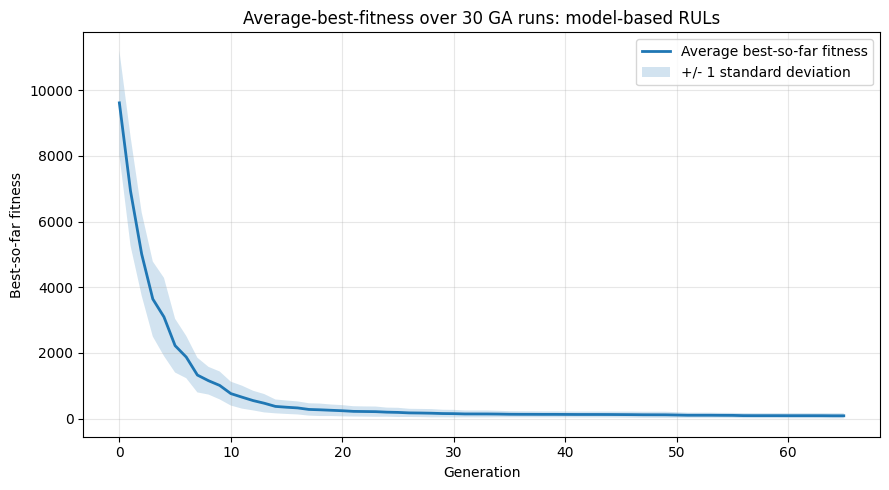

Average-best-fitness plot saved to: C:\Users\yvett\OneDrive\Yvette Laptop Oud\UNIVERSITY\MASTER YEAR 1\M1 Semester 2\Prescriptive_Algorithms\PA_Assignment_3\ga_average_best_fitness_model_predictions.png


In [ ]:
# Plot the average best-so-far fitness.
plt.figure(figsize=(9, 5))

plt.plot(
    predicted_average_best_fitness["generation"],
    predicted_average_best_fitness["mean"],
    linewidth=2,
    label="Average best-so-far fitness"
)

plt.fill_between(
    predicted_average_best_fitness["generation"],
    predicted_average_best_fitness["mean"] - predicted_average_best_fitness["std"],
    predicted_average_best_fitness["mean"] + predicted_average_best_fitness["std"],
    alpha=0.2,
    label="+/- 1 standard deviation"
)

plt.xlabel("Generation")
plt.ylabel("Best-so-far fitness")
plt.title("Average-best-fitness over 30 GA runs: model-based RULs")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

predicted_abf_plot_path = PROJECT_DIR / "ga_average_best_fitness_model_predictions.png"
plt.savefig(predicted_abf_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Average-best-fitness plot saved to: {predicted_abf_plot_path}")

#### 2.2.5 Findings

This section summarizes the optimization results obtained with the model-based RUL predictions.

In [ ]:
# Summarize the 30 model-based GA runs.
predicted_run_statistics = pd.DataFrame({
    "Metric": [
        "Best total penalty",
        "Mean total penalty",
        "Standard deviation total penalty",
        "Worst total penalty",
        "Mean runtime seconds",
        "Maximum runtime seconds",
        "Best run number",
        "Candidate engines",
        "Maintained engines in best run",
        "Feasible best run"
    ],
    "Value": [
        predicted_run_summary["best_total_penalty"].min(),
        predicted_run_summary["best_total_penalty"].mean(),
        predicted_run_summary["best_total_penalty"].std(),
        predicted_run_summary["best_total_penalty"].max(),
        predicted_run_summary["runtime_seconds"].mean(),
        predicted_run_summary["runtime_seconds"].max(),
        int(predicted_run_summary.loc[predicted_run_summary["best_total_penalty"].idxmin(), "run"]),
        int(predicted_run_summary["candidate_engines"].iloc[0]),
        int(predicted_best_repeated_all_engine_solution["maintained"].sum()),
        predicted_best_repeated_validation["is_feasible"]
    ]
})

display(predicted_run_statistics)

,Metric,Value
0,Best total penalty,0
1,Mean total penalty,85.333333
2,Standard deviation total penalty,77.612803
3,Worst total penalty,290
4,Mean runtime seconds,5.553501
5,Maximum runtime seconds,6.227371
6,Best run number,13
7,Candidate engines,18
8,Maintained engines in best run,18
9,Feasible best run,True


In [ ]:
# Keep these variables for the comparison in Section 2.3.
predicted_best_result = predicted_best_repeated_result
predicted_best_all_engine_solution = predicted_best_repeated_all_engine_solution
predicted_best_candidate_solution = predicted_best_repeated_candidate_solution
predicted_best_validation = predicted_best_repeated_validation

print("Optimization with model-based RUL predictions completed.")
print(f"Best total penalty across 30 runs: {predicted_best_validation['total_penalty']}")
print(f"Feasible best solution: {predicted_best_validation['is_feasible']}")

Optimization with model-based RUL predictions completed.
Best total penalty across 30 runs: 0
Feasible best solution: True


### **2.3 Comparison**

This section applies the same Genetic Algorithm to the consultancy RUL predictions.

The results are compared with the optimization results based on the model-based RUL predictions.

#### 2.3.1 Thirty independent GA runs with consultancy RULs

This section runs the Genetic Algorithm 30 times using the consultancy RUL predictions.

The same GA settings are used as in Section 2.2 so that the results are comparable.

In [ ]:
# Run the GA 30 times using the consultancy RUL predictions.
consultancy_runs, consultancy_run_summary, consultancy_logbooks, consultancy_best_repeated_result = run_repeated_ga(
    rul_dict=consultancy_rul_dict,
    label="Consultancy predictions",
    n_runs=30,
    base_seed=RANDOM_SEED + 5000)

display(consultancy_run_summary)

Run 01/30 completed | penalty = 223 | runtime = 6.67s
Run 02/30 completed | penalty = 189 | runtime = 6.23s
Run 03/30 completed | penalty = 306 | runtime = 6.17s
Run 04/30 completed | penalty = 650 | runtime = 6.12s
Run 05/30 completed | penalty = 55 | runtime = 6.30s
Run 06/30 completed | penalty = 256 | runtime = 5.84s
Run 07/30 completed | penalty = 456 | runtime = 5.92s
Run 08/30 completed | penalty = 611 | runtime = 5.69s
Run 09/30 completed | penalty = 147 | runtime = 5.89s
Run 10/30 completed | penalty = 279 | runtime = 7.14s
Run 11/30 completed | penalty = 405 | runtime = 6.17s
Run 12/30 completed | penalty = 279 | runtime = 6.06s
Run 13/30 completed | penalty = 487 | runtime = 5.96s
Run 14/30 completed | penalty = 170 | runtime = 5.81s
Run 15/30 completed | penalty = 244 | runtime = 5.93s
Run 16/30 completed | penalty = 236 | runtime = 5.72s
Run 17/30 completed | penalty = 318 | runtime = 5.69s
Run 18/30 completed | penalty = 404 | runtime = 6.14s
Run 19/30 completed | penalty

,input,run,seed,best_total_penalty,runtime_seconds,candidate_engines
0,Consultancy predictions,1,12350679,223,6.668210,24
1,Consultancy predictions,2,12350680,189,6.225646,24
2,Consultancy predictions,3,12350681,306,6.167756,24
3,Consultancy predictions,4,12350682,650,6.122404,24
4,Consultancy predictions,5,12350683,55,6.296213,24
5,Consultancy predictions,6,12350684,256,5.842041,24
6,Consultancy predictions,7,12350685,456,5.924142,24
7,Consultancy predictions,8,12350686,611,5.687461,24
8,Consultancy predictions,9,12350687,147,5.891421,24
9,Consultancy predictions,10,12350688,279,7.139434,24


#### 2.3.2 Best consultancy-based schedule and validation

This section reports the best found maintenance schedule based on the consultancy RUL predictions.

The schedule is validated using the same checks as for the model-based RUL solution.

In [ ]:
# Store and validate the best solution found across the 30 consultancy-based runs.
consultancy_best_repeated_candidate_solution = consultancy_best_repeated_result["best_solution"]

consultancy_best_repeated_all_engine_solution = format_all_engine_solution(
    consultancy_best_repeated_candidate_solution,
    consultancy_rul_dict)

consultancy_best_repeated_validation = validate_schedule(
    consultancy_best_repeated_all_engine_solution,
    consultancy_rul_dict)

print("Best solution across the 30 consultancy-based GA runs:")
print_validation_report(consultancy_best_repeated_validation)

display(consultancy_best_repeated_candidate_solution)
display(consultancy_best_repeated_all_engine_solution)

Best solution across the 30 consultancy-based GA runs:
Feasible solution: True
Total penalty:     55


,engine_id,maintained,team,team_type,start_day,end_day,duration,safety_due_date,penalty_cost
0,76,1,T3,A,1.0,4.0,4.0,3,6
1,81,1,T4,B,1.0,7.0,7.0,6,6
2,34,1,T2,B,1.0,6.0,6.0,8,0
3,35,1,T1,A,8.0,10.0,3.0,8,10
4,20,1,T3,A,5.0,9.0,5.0,10,0
5,82,1,T1,A,1.0,5.0,5.0,11,0
6,42,1,T1,A,11.0,13.0,3.0,13,0
7,68,1,T2,B,7.0,13.0,7.0,13,0
8,31,1,T3,A,10.0,12.0,3.0,14,0
9,49,1,T3,A,13.0,15.0,3.0,14,5


,engine_id,maintained,team,team_type,start_day,end_day,duration,safety_due_date,penalty_cost
0,1,0,NaN,NaN,NaN,NaN,NaN,135,0
1,2,0,NaN,NaN,NaN,NaN,NaN,125,0
2,3,0,NaN,NaN,NaN,NaN,NaN,63,0
3,4,0,NaN,NaN,NaN,NaN,NaN,100,0
4,5,0,NaN,NaN,NaN,NaN,NaN,103,0
...,...,...,...,...,...,...,...,...,...
95,96,0,NaN,NaN,NaN,NaN,NaN,140,0
96,97,0,NaN,NaN,NaN,NaN,NaN,109,0
97,98,0,NaN,NaN,NaN,NaN,NaN,87,0
98,99,0,NaN,NaN,NaN,NaN,NaN,127,0


In [ ]:
# Compact schedule summary for the best consultancy-based run.
consultancy_best_schedule_summary = pd.DataFrame({
    "Metric": [
        "Total penalty",
        "Maintained engines",
        "Unmaintained engines",
        "Candidate engines",
        "Runtime seconds",
        "Feasible"
    ],
    "Value": [
        consultancy_best_repeated_validation["total_penalty"],
        int(consultancy_best_repeated_all_engine_solution["maintained"].sum()),
        int((consultancy_best_repeated_all_engine_solution["maintained"] == 0).sum()),
        len(consultancy_best_repeated_result["candidate_engines"]),
        consultancy_best_repeated_result["runtime_seconds"],
        consultancy_best_repeated_validation["is_feasible"]
    ]
})

display(consultancy_best_schedule_summary)

,Metric,Value
0,Total penalty,55
1,Maintained engines,23
2,Unmaintained engines,77
3,Candidate engines,24
4,Runtime seconds,6.296213
5,Feasible,True


#### 2.3.3 Average-best-fitness plot

This section plots the average best-so-far fitness over the 30 consultancy-based GA runs.

In [ ]:
# Calculate the average best-so-far fitness over the 30 consultancy-based runs.
consultancy_average_best_fitness = (
    consultancy_logbooks
    .groupby("generation")["best_so_far"]
    .agg(["mean", "std"])
    .reset_index())

display(consultancy_average_best_fitness.head())

,generation,mean,std
0,0,12546.433333,1937.569428
1,1,9729.733333,1506.962369
2,2,8309.666667,1365.718665
3,3,6639.733333,1291.831257
4,4,5078.266667,1243.326487


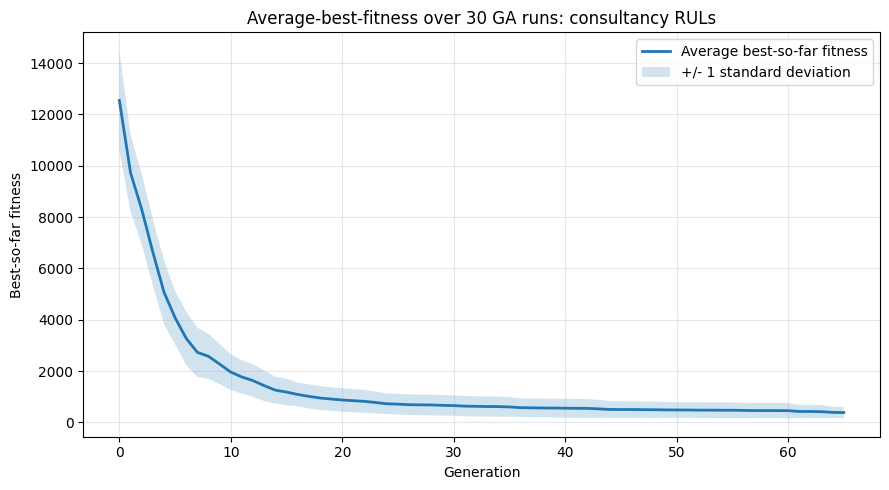

Average-best-fitness plot saved to: C:\Users\yvett\OneDrive\Yvette Laptop Oud\UNIVERSITY\MASTER YEAR 1\M1 Semester 2\Prescriptive_Algorithms\PA_Assignment_3\ga_average_best_fitness_consultancy_predictions.png


In [ ]:
# Plot the average best-so-far fitness for the consultancy-based runs.
plt.figure(figsize=(9, 5))

plt.plot(
    consultancy_average_best_fitness["generation"],
    consultancy_average_best_fitness["mean"],
    linewidth=2,
    label="Average best-so-far fitness")

plt.fill_between(
    consultancy_average_best_fitness["generation"],
    consultancy_average_best_fitness["mean"] - consultancy_average_best_fitness["std"],
    consultancy_average_best_fitness["mean"] + consultancy_average_best_fitness["std"],
    alpha=0.2,
    label="+/- 1 standard deviation")

plt.xlabel("Generation")
plt.ylabel("Best-so-far fitness")
plt.title("Average-best-fitness over 30 GA runs: consultancy RULs")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

consultancy_abf_plot_path = PROJECT_DIR / "ga_average_best_fitness_consultancy_predictions.png"
plt.savefig(consultancy_abf_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Average-best-fitness plot saved to: {consultancy_abf_plot_path}")

#### 2.3.4 Comparison of results

This section compares the optimization results obtained with the model-based RUL predictions and the consultancy RUL predictions.

The comparison focuses on total penalty costs, number of maintained engines, runtime, and convergence behavior.

In [ ]:
# Summarize the 30 consultancy-based GA runs.
consultancy_run_statistics = pd.DataFrame({
    "Metric": [
        "Best total penalty",
        "Mean total penalty",
        "Standard deviation total penalty",
        "Worst total penalty",
        "Mean runtime seconds",
        "Maximum runtime seconds",
        "Best run number",
        "Candidate engines",
        "Maintained engines in best run",
        "Feasible best run"
    ],
    "Value": [
        consultancy_run_summary["best_total_penalty"].min(),
        consultancy_run_summary["best_total_penalty"].mean(),
        consultancy_run_summary["best_total_penalty"].std(),
        consultancy_run_summary["best_total_penalty"].max(),
        consultancy_run_summary["runtime_seconds"].mean(),
        consultancy_run_summary["runtime_seconds"].max(),
        int(consultancy_run_summary.loc[consultancy_run_summary["best_total_penalty"].idxmin(), "run"]),
        int(consultancy_run_summary["candidate_engines"].iloc[0]),
        int(consultancy_best_repeated_all_engine_solution["maintained"].sum()),
        consultancy_best_repeated_validation["is_feasible"]
    ]
})

display(consultancy_run_statistics)

,Metric,Value
0,Best total penalty,55
1,Mean total penalty,382.933333
2,Standard deviation total penalty,222.051087
3,Worst total penalty,1216
4,Mean runtime seconds,6.017256
5,Maximum runtime seconds,7.139434
6,Best run number,5
7,Candidate engines,24
8,Maintained engines in best run,23
9,Feasible best run,True


In [ ]:
# Compare model-based and consultancy-based optimization outcomes.
optimization_comparison = pd.DataFrame({
    "Metric": [
        "Best total penalty",
        "Mean total penalty",
        "Standard deviation total penalty",
        "Worst total penalty",
        "Mean runtime seconds",
        "Maximum runtime seconds",
        "Candidate engines",
        "Maintained engines in best run",
        "Feasible best run"
    ],
    "Model-based RULs": [
        predicted_run_summary["best_total_penalty"].min(),
        predicted_run_summary["best_total_penalty"].mean(),
        predicted_run_summary["best_total_penalty"].std(),
        predicted_run_summary["best_total_penalty"].max(),
        predicted_run_summary["runtime_seconds"].mean(),
        predicted_run_summary["runtime_seconds"].max(),
        int(predicted_run_summary["candidate_engines"].iloc[0]),
        int(predicted_best_all_engine_solution["maintained"].sum()),
        predicted_best_validation["is_feasible"]
    ],
    "Consultancy RULs": [
        consultancy_run_summary["best_total_penalty"].min(),
        consultancy_run_summary["best_total_penalty"].mean(),
        consultancy_run_summary["best_total_penalty"].std(),
        consultancy_run_summary["best_total_penalty"].max(),
        consultancy_run_summary["runtime_seconds"].mean(),
        consultancy_run_summary["runtime_seconds"].max(),
        int(consultancy_run_summary["candidate_engines"].iloc[0]),
        int(consultancy_best_repeated_all_engine_solution["maintained"].sum()),
        consultancy_best_repeated_validation["is_feasible"]
    ]
})

display(optimization_comparison)

,Metric,Model-based RULs,Consultancy RULs
0,Best total penalty,0,55
1,Mean total penalty,85.333333,382.933333
2,Standard deviation total penalty,77.612803,222.051087
3,Worst total penalty,290,1216
4,Mean runtime seconds,5.553501,6.017256
5,Maximum runtime seconds,6.227371,7.139434
6,Candidate engines,18,24
7,Maintained engines in best run,18,23
8,Feasible best run,True,True


In [ ]:
# Compare the best schedules at engine level.
best_schedule_comparison = predicted_best_all_engine_solution[
    ["engine_id", "maintained", "team", "start_day", "end_day", "penalty_cost"]
].rename(columns={
    "maintained": "maintained_model",
    "team": "team_model",
    "start_day": "start_day_model",
    "end_day": "end_day_model",
    "penalty_cost": "penalty_model"
}).merge(
    consultancy_best_repeated_all_engine_solution[
        ["engine_id", "maintained", "team", "start_day", "end_day", "penalty_cost"]
    ].rename(columns={
        "maintained": "maintained_consultancy",
        "team": "team_consultancy",
        "start_day": "start_day_consultancy",
        "end_day": "end_day_consultancy",
        "penalty_cost": "penalty_consultancy"
    }),
    on="engine_id")

best_schedule_comparison["same_maintenance_decision"] = (
    best_schedule_comparison["maintained_model"]
    == best_schedule_comparison["maintained_consultancy"])

best_schedule_comparison["penalty_difference_model_minus_consultancy"] = (
    best_schedule_comparison["penalty_model"]
    - best_schedule_comparison["penalty_consultancy"])

display(best_schedule_comparison.head(20))

,engine_id,maintained_model,team_model,start_day_model,end_day_model,penalty_model,maintained_consultancy,team_consultancy,start_day_consultancy,end_day_consultancy,penalty_consultancy,same_maintenance_decision,penalty_difference_model_minus_consultancy
0,1,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN,0,True,0
1,2,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN,0,True,0
2,3,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN,0,True,0
3,4,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN,0,True,0
4,5,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN,0,True,0
5,6,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN,0,True,0
6,7,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN,0,True,0
7,8,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN,0,True,0
8,9,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN,0,True,0
9,10,0,NaN,NaN,NaN,0,0,NaN,NaN,NaN,0,True,0


In [ ]:
# Compact schedule-difference summary.
schedule_difference_summary = pd.DataFrame({
    "Metric": [
        "Engines with same maintenance decision",
        "Engines with different maintenance decision",
        "Total model-based penalty",
        "Total consultancy-based penalty",
        "Penalty difference model minus consultancy"
    ],
    "Value": [
        int(best_schedule_comparison["same_maintenance_decision"].sum()),
        int((~best_schedule_comparison["same_maintenance_decision"]).sum()),
        int(predicted_best_validation["total_penalty"]),
        int(consultancy_best_repeated_validation["total_penalty"]),
        int(predicted_best_validation["total_penalty"] - consultancy_best_repeated_validation["total_penalty"])
    ]
})

display(schedule_difference_summary)

,Metric,Value
0,Engines with same maintenance decision,93
1,Engines with different maintenance decision,7
2,Total model-based penalty,0
3,Total consultancy-based penalty,55
4,Penalty difference model minus consultancy,-55


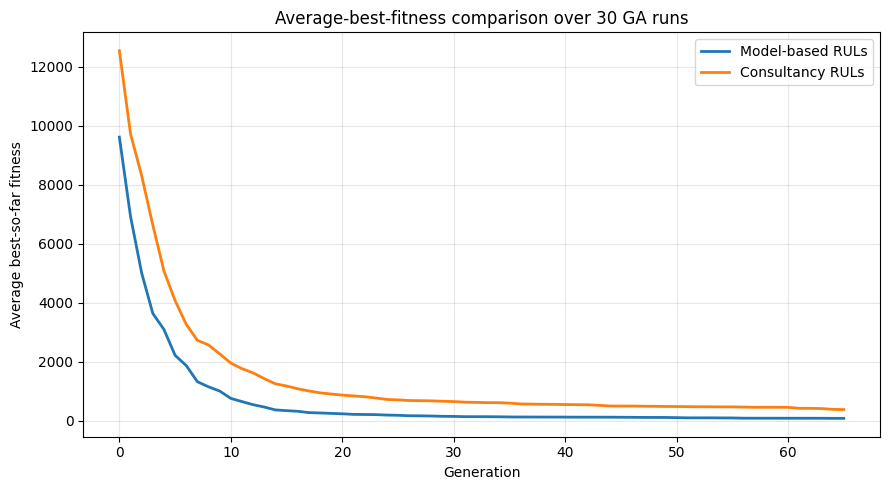

Combined average-best-fitness plot saved to: C:\Users\yvett\OneDrive\Yvette Laptop Oud\UNIVERSITY\MASTER YEAR 1\M1 Semester 2\Prescriptive_Algorithms\PA_Assignment_3\ga_average_best_fitness_comparison.png


In [ ]:
# Plot both average-best-fitness curves together for direct comparison.
plt.figure(figsize=(9, 5))

plt.plot(
    predicted_average_best_fitness["generation"],
    predicted_average_best_fitness["mean"],
    linewidth=2,
    label="Model-based RULs")

plt.plot(
    consultancy_average_best_fitness["generation"],
    consultancy_average_best_fitness["mean"],
    linewidth=2,
    label="Consultancy RULs")

plt.xlabel("Generation")
plt.ylabel("Average best-so-far fitness")
plt.title("Average-best-fitness comparison over 30 GA runs")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

combined_abf_plot_path = PROJECT_DIR / "ga_average_best_fitness_comparison.png"
plt.savefig(combined_abf_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Combined average-best-fitness plot saved to: {combined_abf_plot_path}")

In [ ]:
# Final concise interpretation helper for the report.
best_model_penalty = predicted_best_validation["total_penalty"]
best_consultancy_penalty = consultancy_best_repeated_validation["total_penalty"]

print("Optimization comparison completed.")
print(f"Best model-based total penalty:       {best_model_penalty}")
print(f"Best consultancy-based total penalty: {best_consultancy_penalty}")

if best_model_penalty < best_consultancy_penalty:
    print("The model-based RULs led to a lower best penalty cost than the consultancy RULs.")
elif best_model_penalty > best_consultancy_penalty:
    print("The consultancy RULs led to a lower best penalty cost than the model-based RULs.")
else:
    print("Both RUL inputs led to the same best penalty cost.")

Optimization comparison completed.
Best model-based total penalty:       0
Best consultancy-based total penalty: 55
The model-based RULs led to a lower best penalty cost than the consultancy RULs.
